In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import scorecardpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn import linear_model, metrics
import re
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
##import cleaned dataset
df = pd.read_csv("final_application_data.csv")
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (173647, 81)


In [3]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_11,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AGE_YEARS,EMP_YEARS,TOTAL_ENQUIRIES,BUREAU_RECORD_COUNT,BUREAU_RECENT_CREDIT,BUREAU_AVG_CREDIT_AGE,BUREAU_MEAN_OVERDUE_DAYS,BUREAU_EARLIEST_ENDDATE,BUREAU_LATEST_ENDDATE,BUREAU_LATEST_CLOSED,BUREAU_MAX_AMT_OVERDUE,BUREAU_MAX_PROLONGATIONS,BUREAU_MAX_CREDIT,BUREAU_MEAN_DEBT,BUREAU_TOTAL_LIMIT,BUREAU_TOTAL_AMT_OVERDUE,BUREAU_CREDIT_TYPE_COUNT,BUREAU_OLDEST_UPDATE,BUREAU_TOTAL_ANNUITY,BUREAU_TYPE_CREDIT_CARD,BUREAU_TYPE_MICROLOAN,BUREAU_TYPE_MORTGAGE,BUREAU_TYPE_OTHER,HAS_NO_CLOSED_CREDIT,HAS_NO_ENDDATE,BUREAU_DEBT_UTIL,BUREAU_AVG_PROLONGATIONS,BUREAU_ACTIVE_RATE,BUREAU_BAD_SOLD_RATE,LTV_RATIO,ANNUITY_INCOME_RATIO,DEBT_TO_ANNUITY,DEF_RATE_60,BUREAU_CONSUMER_CREDIT_RATE
count,173647.00,173647.00,173647.00,173646.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,137453.00,173646.00,146758.00,146758.00,146758.00,146758.00,145467.00,145467.00,127665.00,146757.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,104787.00,146758.00,146758.00,146758.00,173647.00,173647.00,173647.00,173647.00,146758.00
mean,278124.14,0.09,0.37,154495.06,26935.99,0.02,-5173.83,-2995.62,0.79,0.21,1.00,0.28,0.05,2.05,12.00,0.01,0.04,0.08,0.21,-956.41,0.00,0.82,0.00,0.02,0.11,0.04,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,44.65,6.71,2.18,5.44,-492.25,-1071.62,1.17,-993.63,4315.99,-536.75,4380.50,0.04,728552.29,126321.02,21319.43,245.41,1.66,-1157.90,17746.33,1.29,0.04,0.05,0.01,0.13,0.01,4.58,0.01,0.41,0.00,1.14,0.19,21.90,0.05,0.74
std,102748.19,0.29,0.69,80982.38,13364.64,0.01,3586.91,1502.46,0.41,0.40,0.02,0.45,0.22,0.50,3.27,0.12,0.21,0.27,0.41,820.15,0.01,0.39,0.01,0.12,0.31,0.19,0.07,0.06,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,11.79,6.70,2.27,4.33,545.02,568.31,27.93,2593.13,9368.53,544.43,63151.30,0.23,1340609.49,426114.67,86236.31,17787.16,0.56,828.90,340235.87,1.48,0.53,0.24,0.13,0.34,0.09,1.25,0.07,0.31,0.04,0.12,0.10,8.05,0.20,0.27
min,100002.00,0.00,0.00,25650.00,1615.50,0.00,-23738.00,-7197.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-4173.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21.00,0.00,0.00,1.00,-2922.00,-2922.00,0.00,-4736.00,-2858.00,-2887.00,0.00,0.00,0.00,-684441.18,0.00,0.00,1.00,-2917.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,8.04,0.00,0.00
25%,189120.00,0.00,0.00,103500.00,17374.50,0.01,-7796.00,-4291.00,1.00,0.00,1.00,0.00,0.00,2.00,10.00,0.00,0.00,0.00,0.00,-1560.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,34.80,2.10,0.00,2.00,-626.00,-1424.83,0.00,-2133.00,84.00,-730.00,0.00,0.00,157500.00,0.00,0.00,0.00,1.00,-1897.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00,0.19,0.00,1.00,0.13,15.27,0.00,0.60
50%,278191.00,0.00,0.00,135000.00,24984.00,0.02,-4677.00,-3242.00,1.00,0.00,1.00,0.00,0.00,2.00,12.00,0.00,0.00,0.00,0.00,-758.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.50,4.50,2.00,4.00,-297.00,-1034.00,0.00,-1270.00,852.00,-351

## Fine Classing

In [4]:
# 1. Feature Selection & Data Preparation
# Exclude identifiers and the target itself
target = 'TARGET'
feature_cols = [df_col for df_col in df.columns if df_col != target and df_col != 'SK_ID_CURR']

print("columns excluded:" + ", ".join([col for col in df.columns if col not in feature_cols]))

# Prepare data: ensure 'Missing' is treated as NaN for scorecardpy
df_processed = df[feature_cols + [target]].copy()
df_processed = df_processed.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_processed[target] = pd.to_numeric(df_processed[target], errors='coerce')
df_processed = df_processed.dropna(subset=[target])
df_processed[target] = df_processed[target].astype(int)


# 2. Target Distribution Check
goods = (df_processed[target] == 0).sum()
bads = (df_processed[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_processed):.2%}")

# 3. Perform Fine Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING FINE CLASSING (Minimum 20 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_processed,
        y=target,
        min_num_bins=20,        # Force fine granularity
        stop_limit=0.0001,      # Smallest IV gain to keep splitting
        count_distr_limit=0.02, # Allow bins as small as 2% of total
        bin_num_limit=50,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# 4. Extract IV Summary
# scorecardpy stores total IV for each variable within each variable's binning dataframe
iv_list = []
for var, df_bin in bins.items():
    if df_bin is not None and not df_bin.empty:
        iv_val = df_bin['total_iv'].iloc[0]
        iv_list.append({
            'Variable': var,
            'IV': iv_val,
            'Bins': len(df_bin)
        })

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

print("\nVariable IV Summary:")
display(iv_df.head(30))

columns excluded:SK_ID_CURR, TARGET

Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING FINE CLASSING (Minimum 20 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 80 columns in 00:01:46

Variable IV Summary:


,Variable,IV,Bins
0,DEBT_TO_ANNUITY,0.19,21
1,EMP_YEARS,0.13,22
2,BUREAU_AVG_CREDIT_AGE,0.13,22
3,AGE_YEARS,0.11,30
4,BUREAU_ACTIVE_RATE,0.10,15
5,OCCUPATION_TYPE,0.09,11
6,ORGANIZATION_TYPE,0.09,15
7,LTV_RATIO,0.08,15
8,BUREAU_RECENT_CREDIT,0.08,19
9,BUREAU_OLDEST_UPDATE,0.07,22


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Extract IV values and Bin Statistics
# ─────────────────────────────────────────────────────────────────────────────

# Extract IV values for all variables using your 'bins' dictionary
iv_summary = {}
woe_details = {}

for var_name, bin_info in bins.items():
    # scorecardpy repeats the total_iv in every row of the binning dataframe
    if isinstance(bin_info, pd.DataFrame) and 'total_iv' in bin_info.columns:
        iv_value = bin_info['total_iv'].iloc[0] if not bin_info.empty else 0
    else:
        iv_value = 0
    
    iv_summary[var_name] = iv_value
    woe_details[var_name] = bin_info

# Create IV summary DataFrame
iv_df = pd.DataFrame({
    'Variable': list(iv_summary.keys()),
    'IV': list(iv_summary.values())
}).sort_values('IV', ascending=False).reset_index(drop=True)

print(f"\n✓ IV values extracted for {len(iv_summary)} variables")
print(f"\nTop 15 variables by IV:")
print("-" * 80)
print(iv_df.head(15).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Bin Count Statistics
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 80)
print("BIN COUNT STATISTICS")
print("-" * 80)

bin_counts = []
for var_name, bin_info in bins.items():
    if isinstance(bin_info, pd.DataFrame):
        # In scorecardpy, each row in bin_info is a distinct bin
        num_bins = len(bin_info)
        bin_counts.append({'Variable': var_name, 'Num_Bins': num_bins})

bin_counts_df = pd.DataFrame(bin_counts).sort_values('Num_Bins', ascending=False)

# Identify variables that successfully reached your 'min_num_bins=20' target
vars_20plus = bin_counts_df[bin_counts_df['Num_Bins'] >= 20]
print(f"\nVariables with 20+ bins:")
print("-" * 80)
print(f"  Count: {len(vars_20plus)} variables")

if len(vars_20plus) > 0:
    print(f"\n  Top variables by bin count:")
    for idx, row in vars_20plus.head(10).iterrows():
        print(f"    - {row['Variable']}: {row['Num_Bins']} bins")

print(f"\n\nOverall Bin Summary:")
print(f"  - Mean bins per variable: {bin_counts_df['Num_Bins'].mean():.1f}")
print(f"  - Median bins per variable: {bin_counts_df['Num_Bins'].median():.1f}")
print(f"  - Max bins: {bin_counts_df['Num_Bins'].max()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed WOE for the Top Variable
# ─────────────────────────────────────────────────────────────────────────────
if not iv_df.empty:
    top_var = iv_df.iloc[0]['Variable']
    print("\n" + "=" * 80)
    print(f"WOE DETAILS FOR TOP VARIABLE: {top_var}")
    print("=" * 80)
    print(f"Total IV: {iv_df.iloc[0]['IV']:.4f}")
    
    if top_var in woe_details:
        top_var_bins = woe_details[top_var]
        # These are the standard scorecardpy columns
        display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
        available_cols = [col for col in display_cols if col in top_var_bins.columns]
        
        print(f"\nDetailed Bin breakdown:")
        print("-" * 80)
        print(top_var_bins[available_cols].to_string(index=False))

print("\n" + "=" * 80)
print("FINE CLASSING COMPLETE")
print("=" * 80)


✓ IV values extracted for 79 variables

Top 15 variables by IV:
--------------------------------------------------------------------------------
               Variable   IV
        DEBT_TO_ANNUITY 0.19
              EMP_YEARS 0.13
  BUREAU_AVG_CREDIT_AGE 0.13
              AGE_YEARS 0.11
     BUREAU_ACTIVE_RATE 0.10
        OCCUPATION_TYPE 0.09
      ORGANIZATION_TYPE 0.09
              LTV_RATIO 0.08
   BUREAU_RECENT_CREDIT 0.08
   BUREAU_OLDEST_UPDATE 0.07
       NAME_INCOME_TYPE 0.07
BUREAU_EARLIEST_ENDDATE 0.07
       BUREAU_MEAN_DEBT 0.06
 DAYS_LAST_PHONE_CHANGE 0.06
        DAYS_ID_PUBLISH 0.05

--------------------------------------------------------------------------------
BIN COUNT STATISTICS
--------------------------------------------------------------------------------

Variables with 20+ bins:
--------------------------------------------------------------------------------
  Count: 13 variables

  Top variables by bin count:
    - AGE_YEARS: 30 bins
    - DAYS_ID_PUBLISH

## Top 15 Feature Selection

In [6]:
top_15_vars = iv_df.head(15)['Variable'].tolist()
df_coarse = df[top_15_vars + ['TARGET', 'SK_ID_CURR']].copy()
df_coarse.head()


,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_AVG_CREDIT_AGE,AGE_YEARS,BUREAU_ACTIVE_RATE,OCCUPATION_TYPE,ORGANIZATION_TYPE,LTV_RATIO,BUREAU_RECENT_CREDIT,BUREAU_OLDEST_UPDATE,NAME_INCOME_TYPE,BUREAU_EARLIEST_ENDDATE,BUREAU_MEAN_DEBT,DAYS_LAST_PHONE_CHANGE,DAYS_ID_PUBLISH,TARGET,SK_ID_CURR
0,16.46,1.70,-874.00,25.90,0.25,Laborers,Business Entity Type 3,1.16,-103.00,-1185.00,Working,-1072.00,49156.20,-1134.00,-2120,1,100002
1,36.23,3.30,-1400.75,45.90,0.25,Core staff,School,1.15,-606.00,-2131.00,State servant,-2434.00,0.00,-828.00,-291,0,100003
2,10.53,8.30,NaN,52.00,NaN,Laborers,Business Entity Type 3,1.05,NaN,NaN,Working,NaN,NaN,-617.00,-2437,0,100006
3,23.46,8.30,-1149.00,54.60,0.00,Core staff,Religion,1.00,-1149.00,-783.00,Working,-783.00,0.00,-1106.00,-3458,0,100007
4,17.82,4.30,-757.33,46.40,0.33,Laborers,Other,1.08,-78.00,-1027.00,State servant,-853.00,80019.00,-2536.00,-477,0,100008


## Coarse Classification

In [7]:
df_coarse = df_coarse.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_coarse[target] = pd.to_numeric(df_coarse[target], errors='coerce')
df_coarse = df_coarse.dropna(subset=[target])
df_coarse[target] = df_coarse[target].astype(int)


# 2. Target Distribution Check
goods = (df_coarse[target] == 0).sum()
bads = (df_coarse[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_coarse):.2%}")

# 3. Perform Coarse Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING COARSE CLASSING (Maximum 10 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_coarse,
        y=target,
        x=top_15_vars,        # Only bin the top 15 variables
        min_num_bins=2,        # Minimum 2 bins to allow for coarse classing
        stop_limit=0.1,      # Smallest IV gain to keep splitting
        count_distr_limit=0.05, # 5% minimum observations per bin
        bin_num_limit=10,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Validate and Extract Coarse Classing Results (Monotonicity fix)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)")
print("="*80)

# Define requirement thresholds
total_n = len(df_coarse)
total_bads = (df_coarse[target] == 1).sum()
total_goods = (df_coarse[target] == 0).sum()

min_obs_per_bin = int(total_n * 0.05)
min_events_per_bin = max(1, int(total_bads * 0.03)) 
min_non_events_per_bin = max(1, int(total_goods * 0.03))

validation_results = []
iv_coarse = {}
woe_details_coarse = {}

for var_name in top_15_vars:
    if var_name not in bins:
        validation_results.append({
            'Variable': var_name, 'Status': 'NOT FOUND', 'Num_Bins': 0,
            'Monotonic': 'N/A', 'Failed_Requirements': 'Variable missing from bins dict'
        })
        continue
    
    bin_data = bins[var_name]
    
    # 1. Check minimum observations and events (usually includes missing)
    min_obs = bin_data['count'].min()
    min_events = bin_data['bad'].min()
    min_non_events = bin_data['good'].min()
    
    # 2. Check monotonicity - FILTER OUT 'missing' bin here
    # We only care if the trend holds for actual data ranges
    monotonic_data = bin_data[bin_data['bin'] != 'missing'].copy()
    woe_values = monotonic_data['woe'].values
    
    if len(woe_values) > 1:
        woe_diff = np.diff(woe_values)
        # Check if all differences are non-negative or all are non-positive
        is_monotonic = (np.all(woe_diff >= 0) or np.all(woe_diff <= 0))
        woe_range = monotonic_data['woe'].max() - monotonic_data['woe'].min()
    else:
        is_monotonic = True # Single data bin is technically monotonic
        woe_range = 0
    
    # 3. Check if requirements are met
    meets_obs_req = min_obs >= min_obs_per_bin
    meets_events_req = min_events >= min_events_per_bin
    meets_non_events_req = min_non_events >= min_non_events_per_bin
    
    failed_reqs = []
    if not meets_obs_req: failed_reqs.append(f"Low_Obs({min_obs})")
    if not meets_events_req: failed_reqs.append(f"Low_Bads({min_events})")
    if not meets_non_events_req: failed_reqs.append(f"Low_Goods({min_non_events})")
    if not is_monotonic: failed_reqs.append("Non-Monotonic")
    
    status = 'PASS' if not failed_reqs else 'FAIL'
    
    validation_results.append({
        'Variable': var_name,
        'Status': status,
        'Num_Bins': len(bin_data),
        'Min_Obs': min_obs,
        'Min_Bads': min_events,
        'Monotonic': 'YES' if is_monotonic else 'NO',
        'Failed_Requirements': "; ".join(failed_reqs) if failed_reqs else "None",
        'WOE_Range': round(woe_range, 4)
    })
    
    iv_coarse[var_name] = bin_data['total_iv'].iloc[0]
    woe_details_coarse[var_name] = bin_data

validation_df = pd.DataFrame(validation_results)

print("\nValidation Results (Top 15 Variables):")
print("-" * 80)
print(validation_df[['Variable', 'Status', 'Num_Bins', 'Monotonic', 'Failed_Requirements']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: IV Comparison (Fine vs Coarse)
# ─────────────────────────────────────────────────────────────────────────────

# Ensure iv_df exists from your previous fine classing step
iv_comparison = pd.DataFrame({
    'Variable': top_15_vars,
    'IV_Fine': [iv_df[iv_df['Variable'] == var]['IV'].values[0] if var in iv_df['Variable'].values else 0 for var in top_15_vars],
    'IV_Coarse': [iv_coarse.get(var, 0) for var in top_15_vars]
})

iv_comparison['IV_Retained_Pct'] = (iv_comparison['IV_Coarse'] / iv_comparison['IV_Fine'] * 100).round(2)

print("\n" + "="*80)
print("IV STABILITY ANALYSIS (Fine vs Coarse)")
print("="*80)
print(iv_comparison.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed Binning for Top Coarse Variable
# ─────────────────────────────────────────────────────────────────────────────

top_var_coarse = iv_comparison.loc[iv_comparison['IV_Coarse'].idxmax(), 'Variable']
print("\n" + "="*80)
print(f"DETAILED COARSE BINNING: {top_var_coarse}")
print("="*80)

if top_var_coarse in woe_details_coarse:
    df_top = woe_details_coarse[top_var_coarse]
    # scorecardpy standard columns
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
    print(df_top[display_cols].to_string(index=False))

print("\n" + "="*80)
print("COARSE CLASSING VALIDATION COMPLETE")
print("="*80)


Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING COARSE CLASSING (Maximum 10 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 16 columns in 00:00:16

VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)

Validation Results (Top 15 Variables):
--------------------------------------------------------------------------------
               Variable Status  Num_Bins Monotonic Failed_Requirements
        DEBT_TO_ANNUITY   FAIL         4        NO       Non-Monotonic
              EMP_YEARS   PASS         5       YES                None
  BUREAU_AVG_CREDIT_AGE   PASS         5       YES                None
              AGE_YEARS   PASS         4       YES                None
     BUREAU_ACTIVE_RATE   PASS         5       YES                None
        OCCUPATION_TYPE   PASS         5       YES                None
      ORGANIZATION_TYPE   PASS         4       YES                None
              LTV_RATIO   FAIL         4    

## WOE Plots

Plotting 15 variables


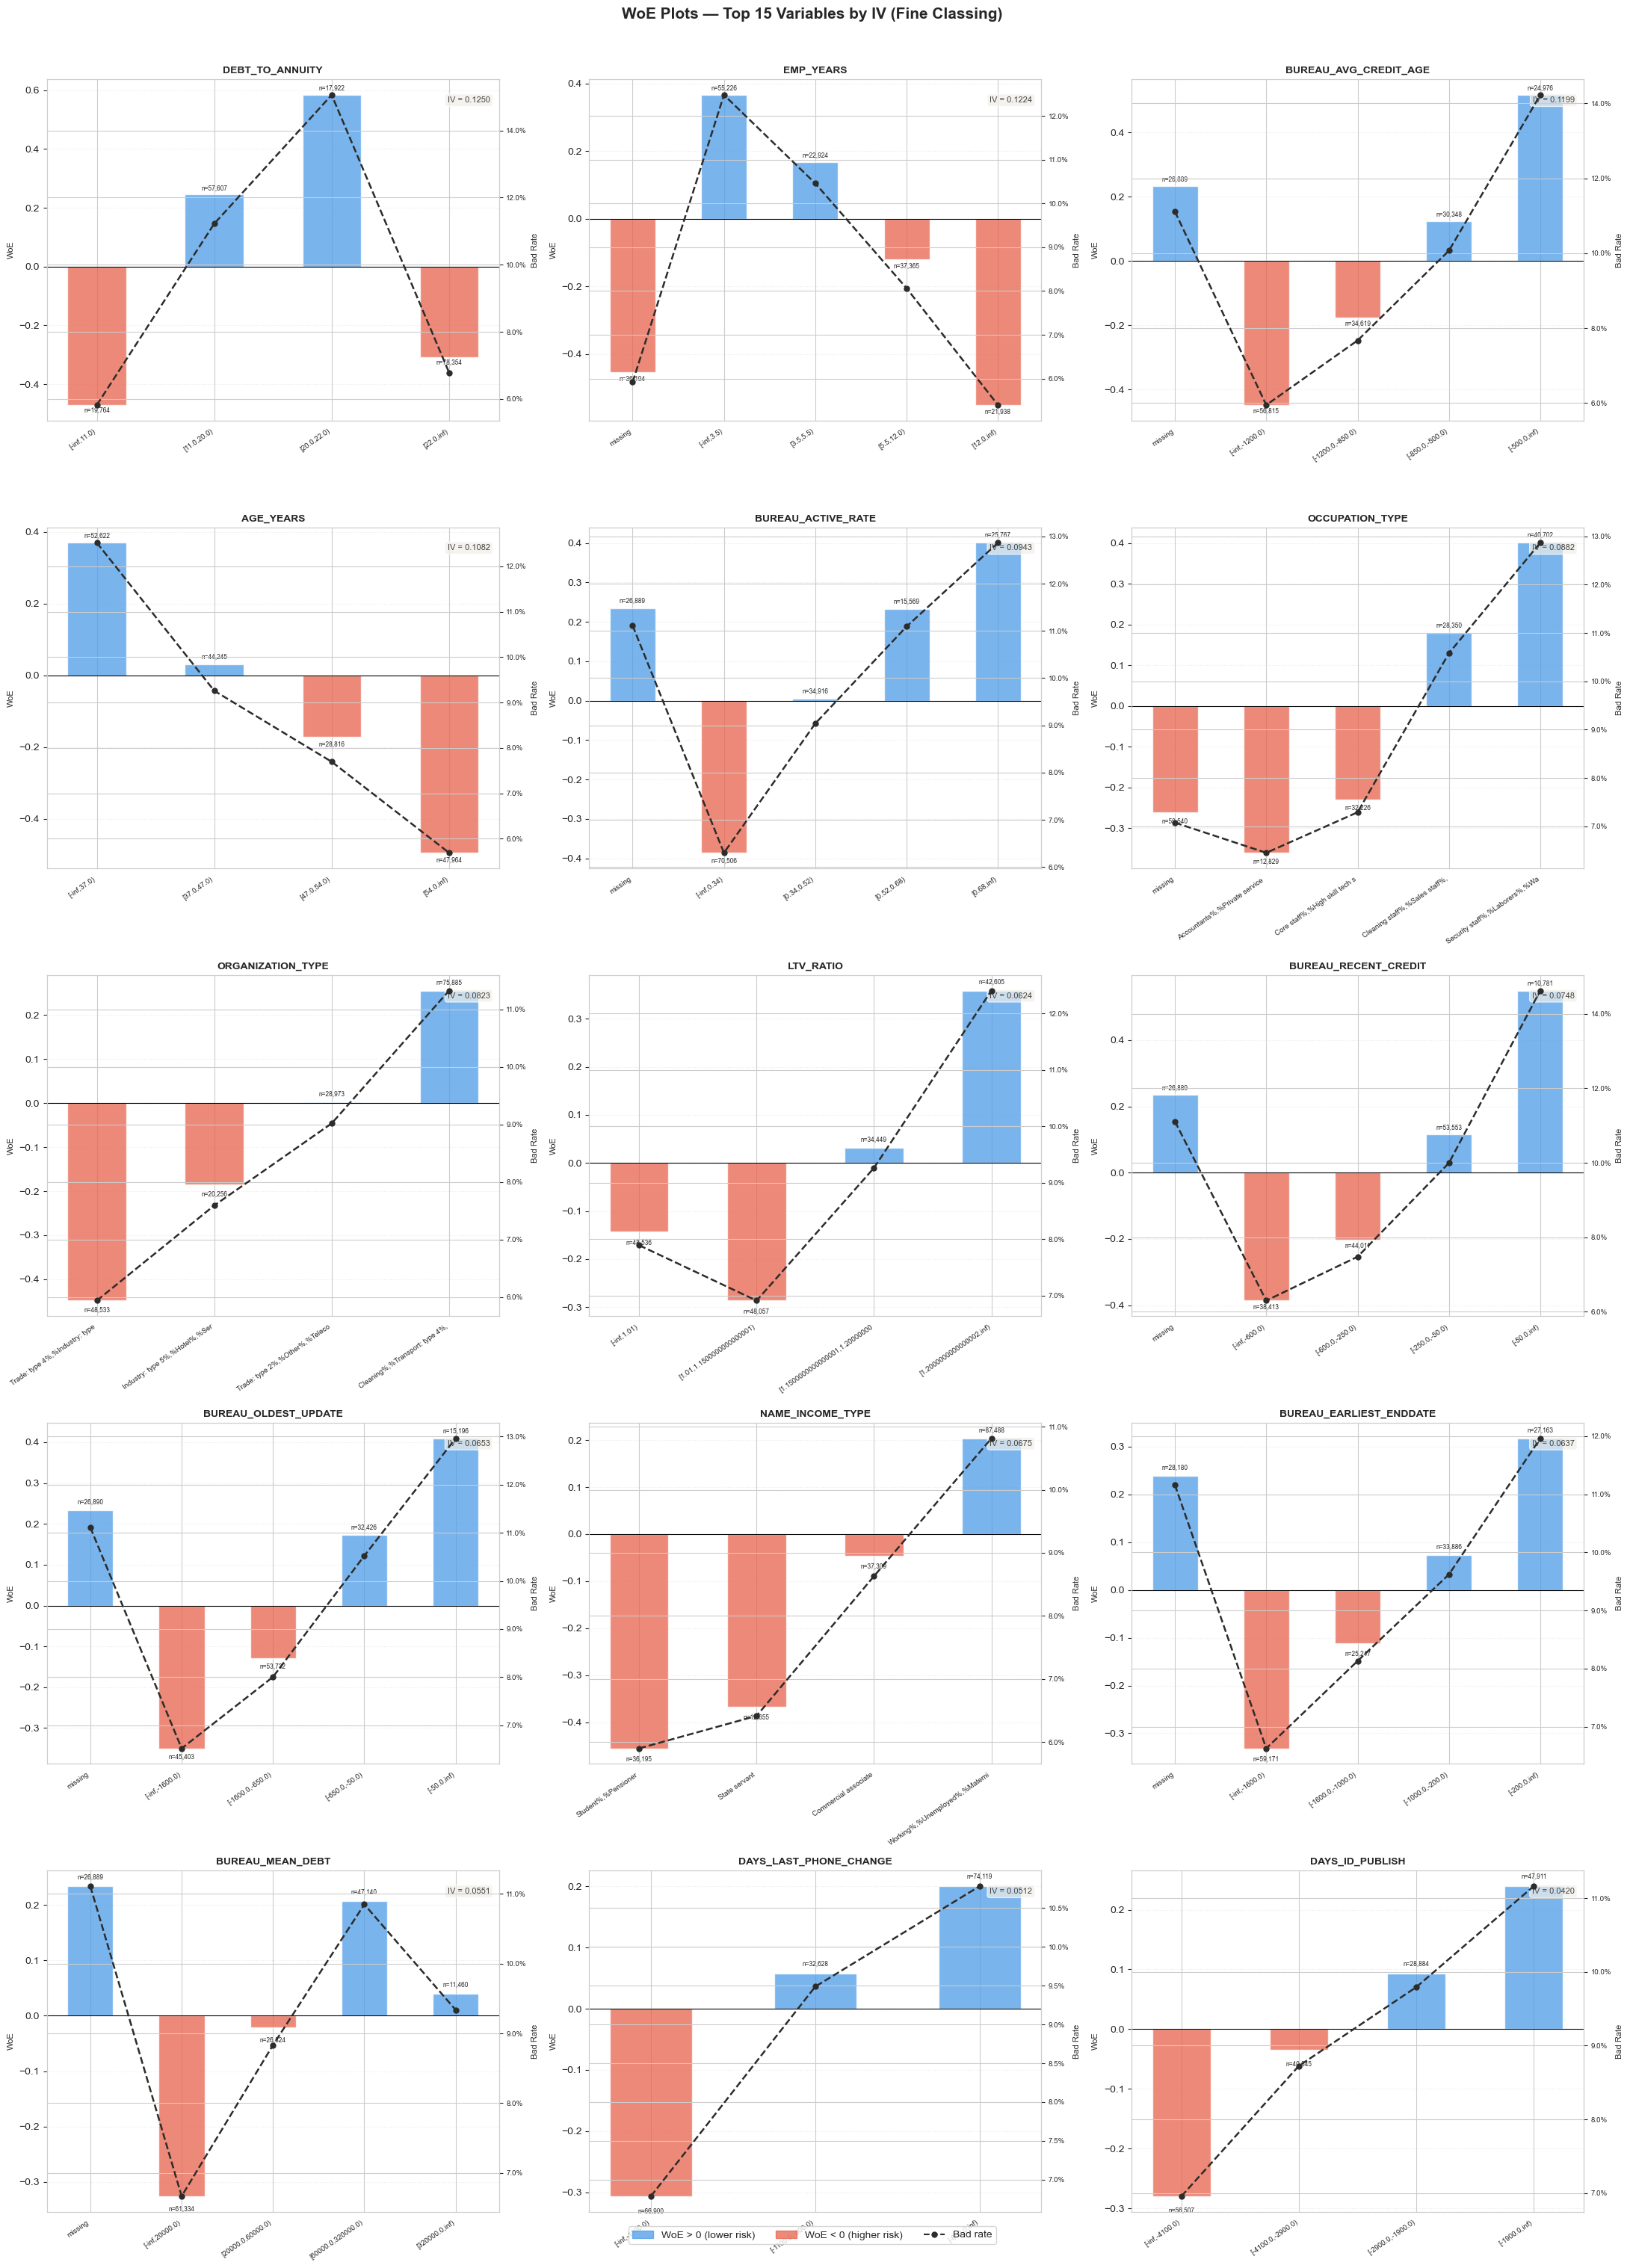

In [8]:
top15_vars = [
    'DEBT_TO_ANNUITY', 'EMP_YEARS', 'BUREAU_AVG_CREDIT_AGE', 'AGE_YEARS',
    'BUREAU_ACTIVE_RATE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'LTV_RATIO',
    'BUREAU_RECENT_CREDIT', 'BUREAU_OLDEST_UPDATE', 'NAME_INCOME_TYPE',
    'BUREAU_EARLIEST_ENDDATE', 'BUREAU_MEAN_DEBT', 'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH'
]

# Filter to variables that exist in bins_fine
vars_to_plot = [v for v in top15_vars if v in bins]
print(f"Plotting {len(vars_to_plot)} variables")

fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    bin_df = bins[var].copy()
    
    # Drop total_iv summary row if present
    if 'total_iv' in bin_df.columns:
        bin_df = bin_df[bin_df['bin'] != 'total_iv'].copy()
    
    # Shorten long bin labels for readability
    bin_df['bin_label'] = bin_df['bin'].astype(str).str[:30]
    
    x = np.arange(len(bin_df))
    woe_vals = bin_df['woe'].values
    bad_prob  = bin_df['badprob'].values if 'badprob' in bin_df.columns else None
    
    # ── Bar: WoE values ──
    colors = ['#E8624C' if w < 0 else '#4C9BE8' for w in woe_vals]
    bars = ax.bar(x, woe_vals, color=colors, alpha=0.75, width=0.5, zorder=2)
    
    # ── Line: Bad rate (secondary axis) ──
    if bad_prob is not None:
        ax2 = ax.twinx()
        ax2.plot(x, bad_prob, color='#2C2C2A', marker='o', markersize=5,
                 linewidth=1.8, linestyle='--', label='Bad rate', zorder=3)
        ax2.set_ylabel('Bad Rate', fontsize=8, color='#2C2C2A')
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%')
        )
    
    # ── Formatting ──
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_df['bin_label'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('WoE', fontsize=8)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
    
    # ── IV annotation ──
    iv_val = bins[var]['total_iv'].iloc[0] \
             if 'total_iv' in bins[var].columns else 0
    ax.annotate(f'IV = {iv_val:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=8, color='#444',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', alpha=0.7))
    
    # ── Count labels on bars ──
    if 'count' in bin_df.columns:
        for bar, cnt in zip(bars, bin_df['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01 if bar.get_height() >= 0 
                    else bar.get_height() - 0.03,
                    f'n={int(cnt):,}', ha='center', va='bottom', fontsize=6)

# Hide unused subplots
for j in range(len(vars_to_plot), len(axes)):
    axes[j].set_visible(False)

# ── Legend ──
pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.75, label='WoE > 0 (lower risk)')
neg_patch = mpatches.Patch(color='#E8624C', alpha=0.75, label='WoE < 0 (higher risk)')
bad_line  = plt.Line2D([0], [0], color='#2C2C2A', linestyle='--',
                        marker='o', markersize=5, label='Bad rate')
fig.legend(handles=[pos_patch, neg_patch, bad_line],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('WoE Plots — Top 15 Variables by IV (Fine Classing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
##investigate non-monotone variables

for var in ['DEBT_TO_ANNUITY', 'LTV_RATIO', 'BUREAU_MEAN_DEBT']:
    print(f"\n{'='*60}")
    print(f"Variable: {var}")
    print(f"{'='*60}")
    bin_df = bins[var].copy()
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'iv']
    available_cols = [c for c in display_cols if c in bin_df.columns]
    print(bin_df[available_cols].to_string(index=False))


Variable: DEBT_TO_ANNUITY
        bin  count  count_distr  good  bad  badprob   woe
[-inf,11.0)  19764         0.11 18614 1150     0.06 -0.47
[11.0,20.0)  57607         0.33 51141 6466     0.11  0.25
[20.0,22.0)  17922         0.10 15223 2699     0.15  0.58
 [22.0,inf)  78354         0.45 73040 5314     0.07 -0.31

Variable: LTV_RATIO
                                    bin  count  count_distr  good  bad  badprob   woe
                            [-inf,1.01)  48536         0.28 44705 3831     0.08 -0.14
              [1.01,1.1500000000000001)  48057         0.28 44735 3322     0.07 -0.29
[1.1500000000000001,1.2000000000000002)  34449         0.20 31258 3191     0.09  0.03
               [1.2000000000000002,inf)  42605         0.25 37320 5285     0.12  0.36

Variable: BUREAU_MEAN_DEBT
               bin  count  count_distr  good  bad  badprob   woe
           missing  26889         0.15 23901 2988     0.11  0.23
    [-inf,20000.0)  61334         0.35 57247 4087     0.07 -0.33
 [20000.0

In [10]:
breaks_adj = {
    'DEBT_TO_ANNUITY'  : [20.0],
    'LTV_RATIO'        : [1.15, 1.20],
    'BUREAU_MEAN_DEBT' : [20000, 60000],
}

# Re-bin only the 3 non-monotone variables on the full df_coarse
bins_fixed = sc.woebin(
    df_coarse,
    y=target,
    x=list(breaks_adj.keys()),
    breaks_list=breaks_adj,
    positive='bad|1',
    ignore_datetime_cols=False,
    check_cate_num=False
)

bins.update(bins_fixed)

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Validate and Extract Coarse Classing Results (Monotonicity fix)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)")
print("="*80)

# Define requirement thresholds
total_n = len(df_coarse)
total_bads = (df_coarse[target] == 1).sum()
total_goods = (df_coarse[target] == 0).sum()

min_obs_per_bin = int(total_n * 0.05)
min_events_per_bin = max(1, int(total_bads * 0.03)) 
min_non_events_per_bin = max(1, int(total_goods * 0.03))

validation_results = []
iv_coarse = {}
woe_details_coarse = {}

for var_name in top_15_vars:
    if var_name not in bins:
        validation_results.append({
            'Variable': var_name, 'Status': 'NOT FOUND', 'Num_Bins': 0,
            'Monotonic': 'N/A', 'Failed_Requirements': 'Variable missing from bins bins dict'
        })
        continue
    
    bin_data = bins[var_name]
    
    # 1. Check minimum observations and events (usually includes missing)
    min_obs = bin_data['count'].min()
    min_events = bin_data['bad'].min()
    min_non_events = bin_data['good'].min()
    
    # 2. Check monotonicity - FILTER OUT 'missing' bin here
    # We only care if the trend holds for actual data ranges
    monotonic_data = bin_data[bin_data['bin'] != 'missing'].copy()
    woe_values = monotonic_data['woe'].values
    
    if len(woe_values) > 1:
        woe_diff = np.diff(woe_values)
        # Check if all differences are non-negative or all are non-positive
        is_monotonic = (np.all(woe_diff >= 0) or np.all(woe_diff <= 0))
        woe_range = monotonic_data['woe'].max() - monotonic_data['woe'].min()
    else:
        is_monotonic = True # Single data bin is technically monotonic
        woe_range = 0
    
    # 3. Check if requirements are met
    meets_obs_req = min_obs >= min_obs_per_bin
    meets_events_req = min_events >= min_events_per_bin
    meets_non_events_req = min_non_events >= min_non_events_per_bin
    
    failed_reqs = []
    if not meets_obs_req: failed_reqs.append(f"Low_Obs({min_obs})")
    if not meets_events_req: failed_reqs.append(f"Low_Bads({min_events})")
    if not meets_non_events_req: failed_reqs.append(f"Low_Goods({min_non_events})")
    if not is_monotonic: failed_reqs.append("Non-Monotonic")
    
    status = 'PASS' if not failed_reqs else 'FAIL'
    
    validation_results.append({
        'Variable': var_name,
        'Status': status,
        'Num_Bins': len(bin_data),
        'Min_Obs': min_obs,
        'Min_Bads': min_events,
        'Monotonic': 'YES' if is_monotonic else 'NO',
        'Failed_Requirements': "; ".join(failed_reqs) if failed_reqs else "None",
        'WOE_Range': round(woe_range, 4)
    })
    
    iv_coarse[var_name] = bin_data['total_iv'].iloc[0]
    woe_details_coarse[var_name] = bin_data

validation_df = pd.DataFrame(validation_results)

print("\nValidation Results (Top 15 Variables):")
print("-" * 80)
print(validation_df[['Variable', 'Status', 'Num_Bins', 'Monotonic', 'Failed_Requirements']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: IV Comparison (Fine vs Coarse)
# ─────────────────────────────────────────────────────────────────────────────

# Ensure iv_df exists from your previous fine classing step
iv_comparison = pd.DataFrame({
    'Variable': top_15_vars,
    'IV_Fine': [iv_df[iv_df['Variable'] == var]['IV'].values[0] if var in iv_df['Variable'].values else 0 for var in top_15_vars],
    'IV_Coarse': [iv_coarse.get(var, 0) for var in top_15_vars]
})

iv_comparison['IV_Retained_Pct'] = (iv_comparison['IV_Coarse'] / iv_comparison['IV_Fine'] * 100).round(2)

print("\n" + "="*80)
print("IV STABILITY ANALYSIS (Fine vs Coarse)")
print("="*80)
print(iv_comparison.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed Binning for Top Coarse Variable
# ─────────────────────────────────────────────────────────────────────────────

top_var_coarse = iv_comparison.loc[iv_comparison['IV_Coarse'].idxmax(), 'Variable']
print("\n" + "="*80)
print(f"DETAILED COARSE BINNING: {top_var_coarse}")
print("="*80)

if top_var_coarse in woe_details_coarse:
    df_top = woe_details_coarse[top_var_coarse]
    # scorecardpy standard columns
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
    print(df_top[display_cols].to_string(index=False))

print("\n" + "="*80)
print("COARSE CLASSING VALIDATION COMPLETE")
print("="*80)


[INFO] creating woe binning ...

VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)

Validation Results (Top 15 Variables):
--------------------------------------------------------------------------------
               Variable Status  Num_Bins Monotonic Failed_Requirements
        DEBT_TO_ANNUITY   PASS         2       YES                None
              EMP_YEARS   PASS         5       YES                None
  BUREAU_AVG_CREDIT_AGE   PASS         5       YES                None
              AGE_YEARS   PASS         4       YES                None
     BUREAU_ACTIVE_RATE   PASS         5       YES                None
        OCCUPATION_TYPE   PASS         5       YES                None
      ORGANIZATION_TYPE   PASS         4       YES                None
              LTV_RATIO   PASS         3       YES                None
   BUREAU_RECENT_CREDIT   PASS         5       YES                None
   BUREAU_OLDEST_UPDATE   PASS         5       YES                No

Plotting 15 variables


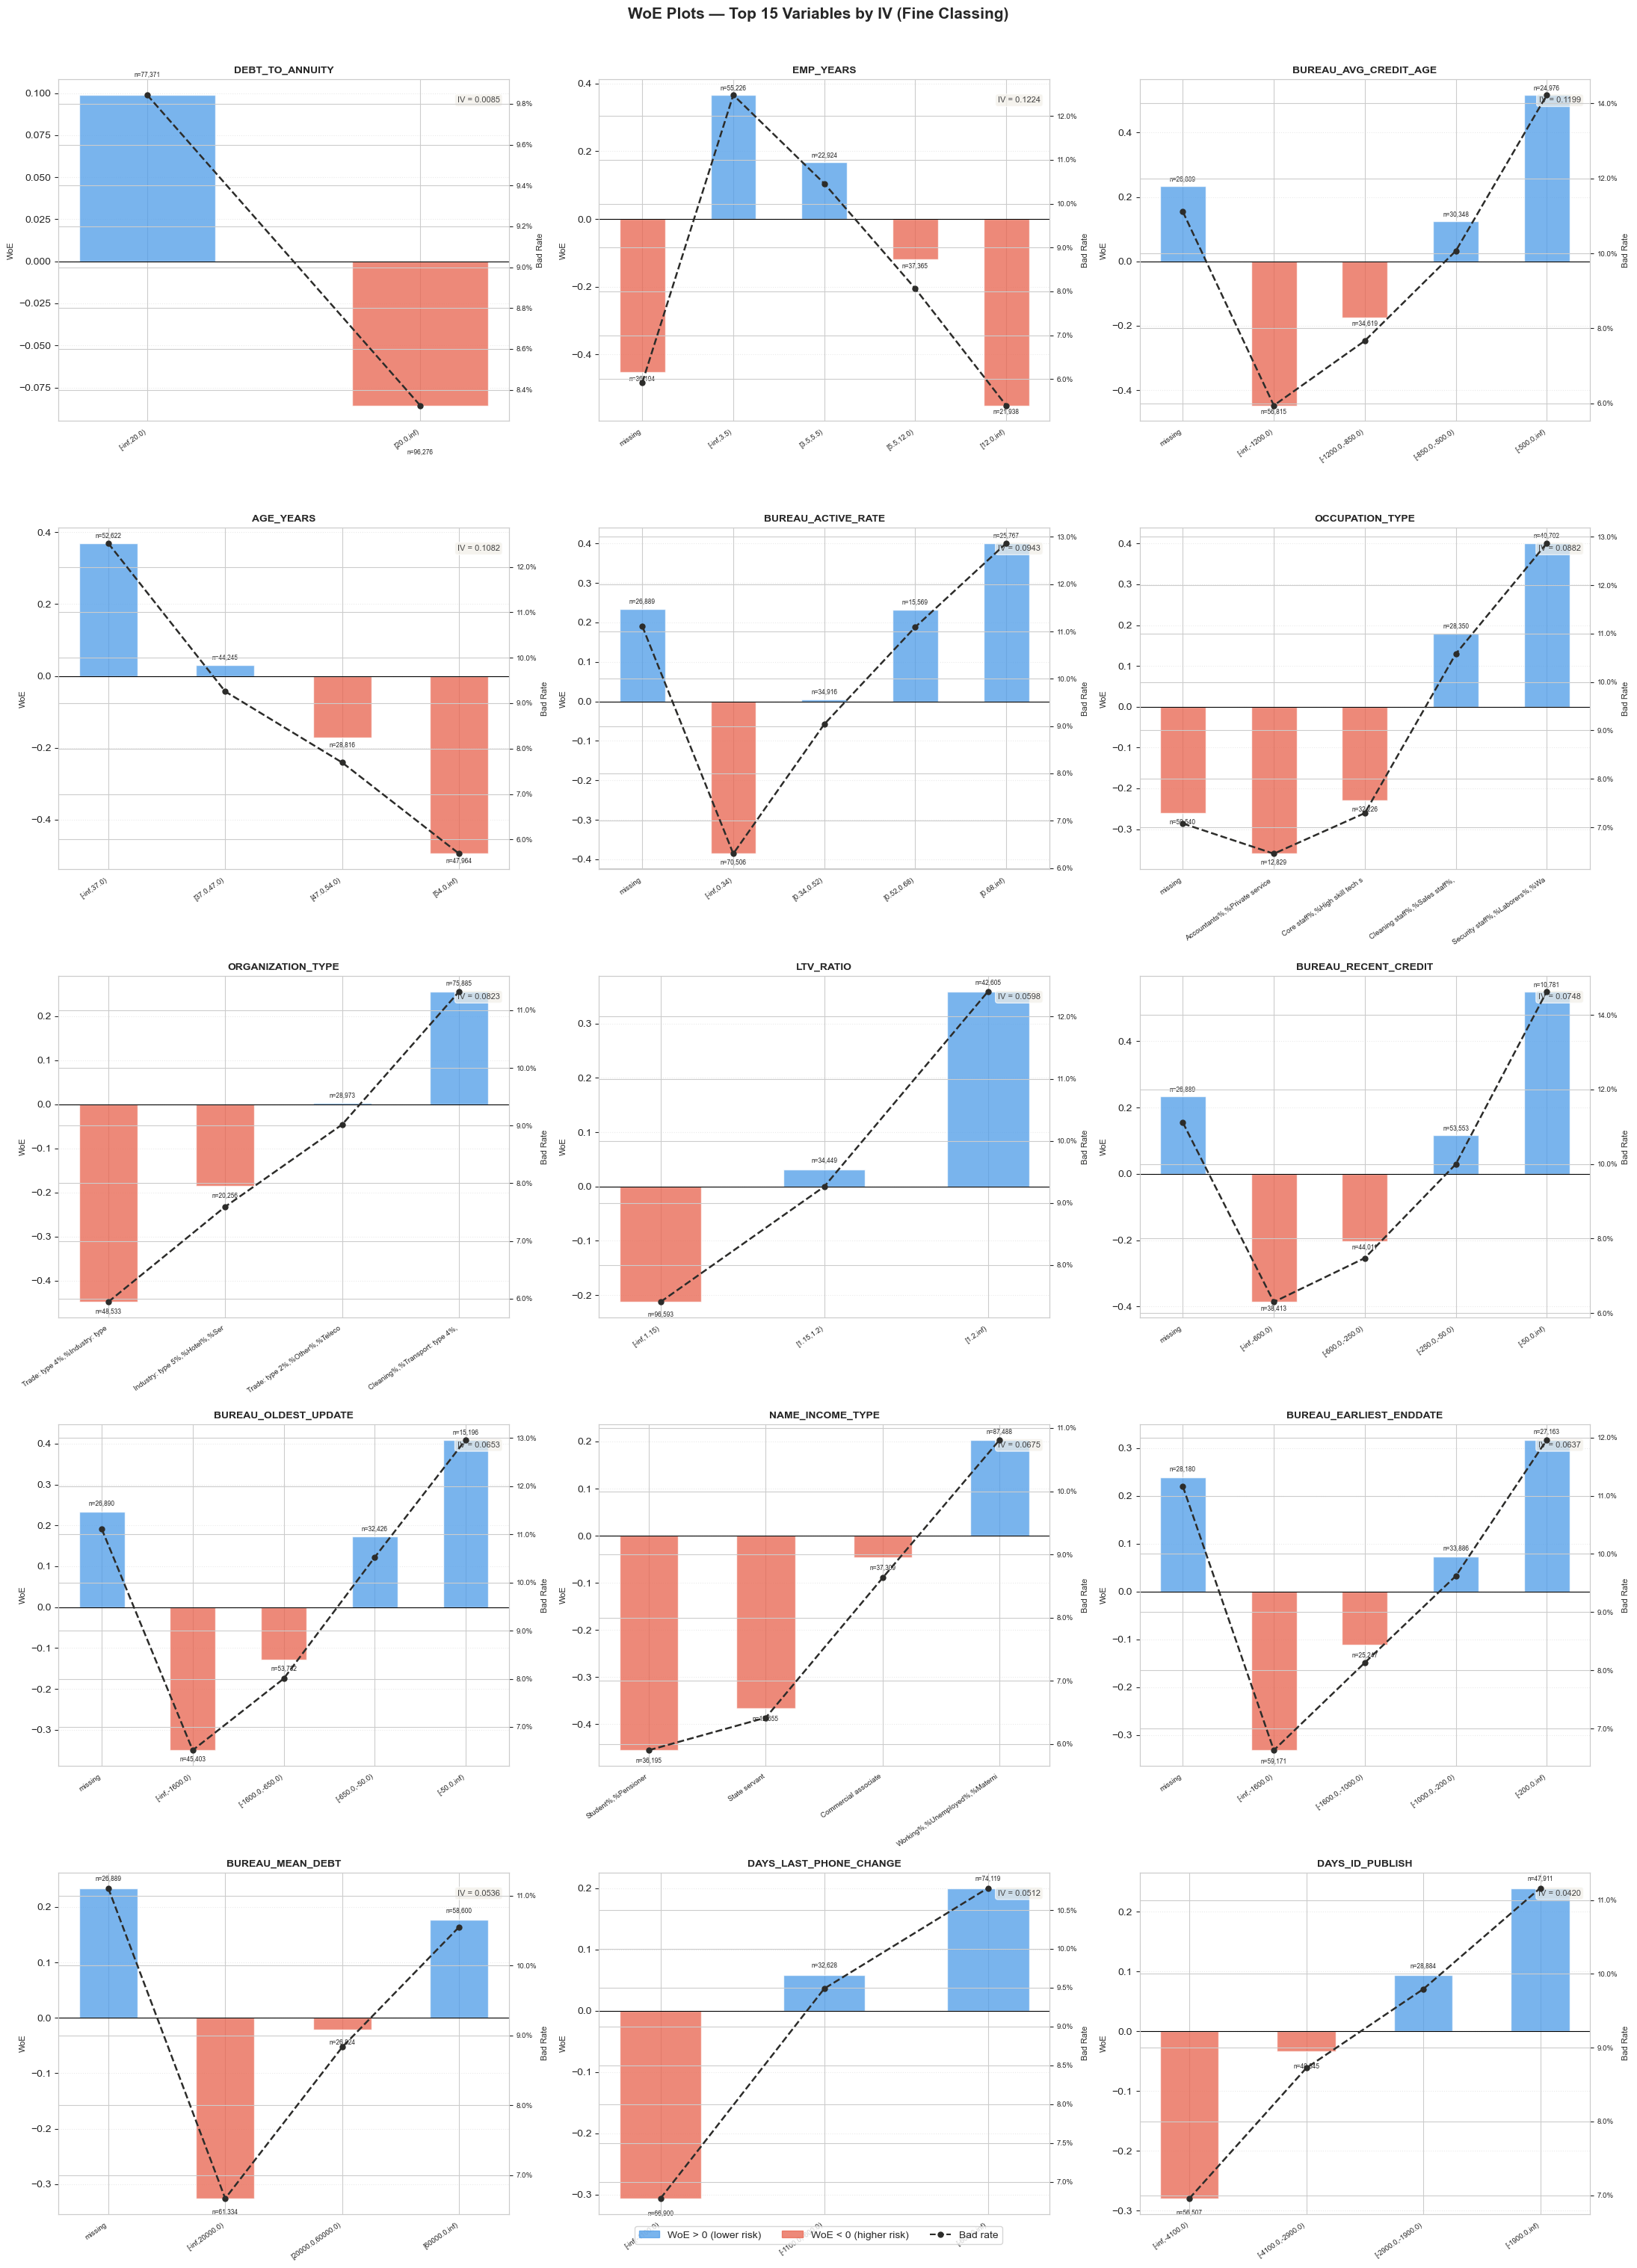

In [11]:
top15_vars = [
    'DEBT_TO_ANNUITY', 'EMP_YEARS', 'BUREAU_AVG_CREDIT_AGE', 'AGE_YEARS',
    'BUREAU_ACTIVE_RATE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'LTV_RATIO',
    'BUREAU_RECENT_CREDIT', 'BUREAU_OLDEST_UPDATE', 'NAME_INCOME_TYPE',
    'BUREAU_EARLIEST_ENDDATE', 'BUREAU_MEAN_DEBT', 'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH'
]

# Filter to variables that exist in bins_fine
vars_to_plot = [v for v in top15_vars if v in bins]
print(f"Plotting {len(vars_to_plot)} variables")

fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    bin_df = bins[var].copy()
    
    # Drop total_iv summary row if present
    if 'total_iv' in bin_df.columns:
        bin_df = bin_df[bin_df['bin'] != 'total_iv'].copy()
    
    # Shorten long bin labels for readability
    bin_df['bin_label'] = bin_df['bin'].astype(str).str[:30]
    
    x = np.arange(len(bin_df))
    woe_vals = bin_df['woe'].values
    bad_prob  = bin_df['badprob'].values if 'badprob' in bin_df.columns else None
    
    # ── Bar: WoE values ──
    colors = ['#E8624C' if w < 0 else '#4C9BE8' for w in woe_vals]
    bars = ax.bar(x, woe_vals, color=colors, alpha=0.75, width=0.5, zorder=2)
    
    # ── Line: Bad rate (secondary axis) ──
    if bad_prob is not None:
        ax2 = ax.twinx()
        ax2.plot(x, bad_prob, color='#2C2C2A', marker='o', markersize=5,
                 linewidth=1.8, linestyle='--', label='Bad rate', zorder=3)
        ax2.set_ylabel('Bad Rate', fontsize=8, color='#2C2C2A')
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%')
        )
    
    # ── Formatting ──
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_df['bin_label'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('WoE', fontsize=8)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
    
    # ── IV annotation ──
    iv_val = bins[var]['total_iv'].iloc[0] \
             if 'total_iv' in bins[var].columns else 0
    ax.annotate(f'IV = {iv_val:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=8, color='#444',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', alpha=0.7))
    
    # ── Count labels on bars ──
    if 'count' in bin_df.columns:
        for bar, cnt in zip(bars, bin_df['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01 if bar.get_height() >= 0 
                    else bar.get_height() - 0.03,
                    f'n={int(cnt):,}', ha='center', va='bottom', fontsize=6)

# Hide unused subplots
for j in range(len(vars_to_plot), len(axes)):
    axes[j].set_visible(False)

# ── Legend ──
pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.75, label='WoE > 0 (lower risk)')
neg_patch = mpatches.Patch(color='#E8624C', alpha=0.75, label='WoE < 0 (higher risk)')
bad_line  = plt.Line2D([0], [0], color='#2C2C2A', linestyle='--',
                        marker='o', markersize=5, label='Bad rate')
fig.legend(handles=[pos_patch, neg_patch, bad_line],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('WoE Plots — Top 15 Variables by IV (Fine Classing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# WOE Encoding + Logistic Regression Training Model

## Train / Test Split

In [12]:
# scorecardpy split
dt_s = sc.split_df(df_coarse, y=target, ratio=0.7)

train = dt_s['train']
test = dt_s['test']

summary = pd.DataFrame({
    "Dataset": ["Overall", "Training Set", "Test Set"],
    "Number of Observations": [len(df_coarse), len(train), len(test)],
    "Bad Rates": [
        df_coarse[target].mean(),
        train[target].mean(),
        test[target].mean()
    ],
    "Bad Counts": [
        df_coarse[target].sum(),
        train[target].sum(),
        test[target].sum()
    ]
})

summary
print("Training Set - Head 10")
display(train.head(10))

print("Test Set - Head 10")
display(test.head(10))

Training Set - Head 10


,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_AVG_CREDIT_AGE,AGE_YEARS,BUREAU_ACTIVE_RATE,OCCUPATION_TYPE,ORGANIZATION_TYPE,LTV_RATIO,BUREAU_RECENT_CREDIT,BUREAU_OLDEST_UPDATE,NAME_INCOME_TYPE,BUREAU_EARLIEST_ENDDATE,BUREAU_MEAN_DEBT,DAYS_LAST_PHONE_CHANGE,DAYS_ID_PUBLISH,TARGET,SK_ID_CURR
0,16.46,1.70,-874.00,25.90,0.25,Laborers,Business Entity Type 3,1.16,-103.00,-1185.00,Working,-1072.00,49156.20,-1134.00,-2120,1,100002
1,36.23,3.30,-1400.75,45.90,0.25,Core staff,School,1.15,-606.00,-2131.00,State servant,-2434.00,0.00,-828.00,-291,0,100003
2,10.53,8.30,NaN,52.00,NaN,Laborers,Business Entity Type 3,1.05,NaN,NaN,Working,NaN,NaN,-617.00,-2437,0,100006
3,23.46,8.30,-1149.00,54.60,0.00,Core staff,Religion,1.00,-1149.00,-783.00,Working,-783.00,0.00,-1106.00,-3458,0,100007
4,17.82,4.30,-757.33,46.40,0.33,Laborers,Other,1.08,-78.00,-1027.00,State servant,-853.00,80019.00,-2536.00,-477,0,100008
6,30.81,1.90,-1095.38,27.90,0.25,Core staff,Medicine,1.00,-376.00,-1991.00,Working,-2004.00,151642.80,-844.00,-738,0,100014
7,13.89,NaN,-947.75,55.90,0.00,NaN,XNA,1.10,-319.00,-904.00,Pensioner,-1045.00,0.00,-2396.00,-2512,0,100015
8,13.75,7.40,-618.43,36.80,0.57,Laborers,Business Entity Type 2,1.20,-128.00,-1367.00,Working,-1369.00,12744.90,-2370.00,-3227,0,100016
10,19.49,3.60,-261.50,35.40,0.50,Drivers,Government,1.32,-90.00,-310.00,Working,-311.00,30772.12,-3.00,-3866,0,100020
11,31.00,5.60,-1164.38,31.10,0.31,Core staff,Kindergarten,1.20,-157.00,-2287.00,State servant,-2228.00,13703.85,-1850.00,-3964,0,100023


Test Set - Head 10


,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_AVG_CREDIT_AGE,AGE_YEARS,BUREAU_ACTIVE_RATE,OCCUPATION_TYPE,ORGANIZATION_TYPE,LTV_RATIO,BUREAU_RECENT_CREDIT,BUREAU_OLDEST_UPDATE,NAME_INCOME_TYPE,BUREAU_EARLIEST_ENDDATE,BUREAU_MEAN_DEBT,DAYS_LAST_PHONE_CHANGE,DAYS_ID_PUBLISH,TARGET,SK_ID_CURR
5,30.14,NaN,-1773.00,55.00,0.00,NaN,XNA,1.12,-1309.00,-2172.00,Pensioner,-2173.00,0.00,0.00,-3514,0,100011
9,23.60,0.60,NaN,39.90,NaN,Laborers,Transport: type 2,1.14,NaN,NaN,Working,NaN,NaN,-188.00,-2056,0,100018
13,20.32,9.60,-930.83,52.90,0.33,Cleaning staff,Business Entity Type 3,1.00,-418.00,-1173.00,Working,-1173.00,75273.75,0.00,-2893,0,100030
14,36.19,7.20,-579.57,51.30,0.43,Cooking staff,Business Entity Type 3,1.40,-75.00,-989.00,Working,-269.00,562500.00,-161.00,-1827,1,100031
15,13.72,3.40,-1071.00,43.70,0.25,Laborers,Industry: type 11,1.21,-556.00,-652.00,Working,-662.00,0.00,-2.00,-3153,0,100032
21,27.69,2.10,-1904.00,47.10,0.00,Private service staff,Other,1.16,-1169.00,-2513.00,Commercial associate,-2453.00,0.00,-2411.00,-735,0,100043
23,34.08,3.50,-1104.80,47.90,0.60,Laborers,Business Entity Type 3,1.40,-420.00,-1140.00,Commercial associate,-960.00,805114.12,-1075.00,-1029,1,100047
24,20.69,1.30,-75.00,46.50,0.00,Laborers,Industry: type 1,1.12,-75.00,-61.00,Working,-66.00,0.00,-458.00,-513,0,100048
34,9.17,10.20,-872.00,33.50,1.00,NaN,University,1.07,-83.00,-425.00,Working,-1463.00,136946.25,-280.00,-4541,0,100075
36,21.32,7.80,-1133.41,32.90,0.29,Laborers,Business Entity Type 3,1.00,-65.00,-1517.00,Commercial associate,-1469.00,238475.24,-1003.00,-3656,0,100082


## WOE Encoding

In [13]:
top_15_vars = [
    'DEBT_TO_ANNUITY', 
    'EMP_YEARS', 
    'BUREAU_AVG_CREDIT_AGE', 
    'AGE_YEARS',
    'BUREAU_ACTIVE_RATE', 
    'OCCUPATION_TYPE', 
    'ORGANIZATION_TYPE', 
    'LTV_RATIO',
    'BUREAU_RECENT_CREDIT', 
    'BUREAU_OLDEST_UPDATE', 
    'NAME_INCOME_TYPE',
    'BUREAU_EARLIEST_ENDDATE', 
    'BUREAU_MEAN_DEBT', 
    'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH' 
]

bins_final = sc.woebin(
    train,
    y=target,
    x=top_15_vars,
    min_num_bins=2,
    max_num_bins=10,
    positive='bad|1',
    ignore_datetime_cols=False,
    check_cate_num=False,    
    breaks_list=breaks_adj, # Use the adjusted breaks to ensure monotonicity for the 3 vars ##### IMPORTANT: Comment out this line if you dont want to apply the monotonicity fixes done above
)

train_woe = sc.woebin_ply(train, bins_final, print_step=0)
test_woe  = sc.woebin_ply(test, bins_final, print_step=0)

print(train_woe.shape)
print(test_woe.shape)
train_woe.head()

[INFO] creating woe binning ...
Binning on 121553 rows and 16 columns in 00:00:11
[INFO] converting into woe values ...
[INFO] converting into woe values ...
(121553, 17)
(52094, 17)


,TARGET,SK_ID_CURR,LTV_RATIO_woe,BUREAU_AVG_CREDIT_AGE_woe,DAYS_LAST_PHONE_CHANGE_woe,EMP_YEARS_woe,DEBT_TO_ANNUITY_woe,BUREAU_RECENT_CREDIT_woe,DAYS_ID_PUBLISH_woe,AGE_YEARS_woe,BUREAU_OLDEST_UPDATE_woe,ORGANIZATION_TYPE_woe,NAME_INCOME_TYPE_woe,BUREAU_MEAN_DEBT_woe,OCCUPATION_TYPE_woe,BUREAU_EARLIEST_ENDDATE_woe,BUREAU_ACTIVE_RATE_woe
0,1,100002,0.04,-0.13,-0.27,0.38,0.10,0.10,0.20,0.37,-0.10,0.25,0.20,-0.03,0.26,-0.10,-0.39
1,0,100003,-0.21,-0.45,0.16,0.19,-0.09,-0.38,0.20,-0.11,-0.37,-0.47,-0.36,-0.33,-0.26,-0.35,-0.39
2,0,100006,-0.21,0.24,0.16,-0.09,0.10,0.24,0.20,-0.11,0.24,0.25,0.20,0.24,0.26,0.25,0.24
3,0,100007,-0.21,-0.13,-0.27,-0.09,-0.09,-0.38,-0.01,-0.49,-0.10,-0.47,0.20,-0.33,-0.26,0.01,-0.39
4,0,100008,-0.21,-0.13,-0.49,0.19,0.10,0.10,0.20,-0.11,-0.10,-0.01,-0.36,0.18,0.26,0.01,-0.39


## Model Training

In [14]:
woe_cols = sorted([col for col in train_woe.columns if col.endswith('_woe')]) #Add a sort here to fix the problem of different column order causing masively different scorecard points
X_train = train_woe[woe_cols]
y_train = train_woe[target]

X_test = test_woe[woe_cols]
y_test = test_woe[target]

logreg = linear_model.LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    random_state=42,
)

logreg.fit(X_train, y_train)

# Extract intercept
intercept = logreg.intercept_[0]

# Create coefficient table (including intercept)
coef_df = pd.DataFrame({
    'Variable': ['Intercept'] + woe_cols,
    'Coefficient': np.concatenate([[intercept], logreg.coef_[0]])
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df

,Variable,Coefficient
12,LTV_RATIO_woe,0.86
9,DAYS_LAST_PHONE_CHANGE_woe,0.63
3,BUREAU_AVG_CREDIT_AGE_woe,0.59
14,OCCUPATION_TYPE_woe,0.58
10,DEBT_TO_ANNUITY_woe,0.51
2,BUREAU_ACTIVE_RATE_woe,0.46
1,AGE_YEARS_woe,0.40
5,BUREAU_MEAN_DEBT_woe,0.37
7,BUREAU_RECENT_CREDIT_woe,0.37
11,EMP_YEARS_woe,0.36


## Model Evaluation

KS Score: 0.2430


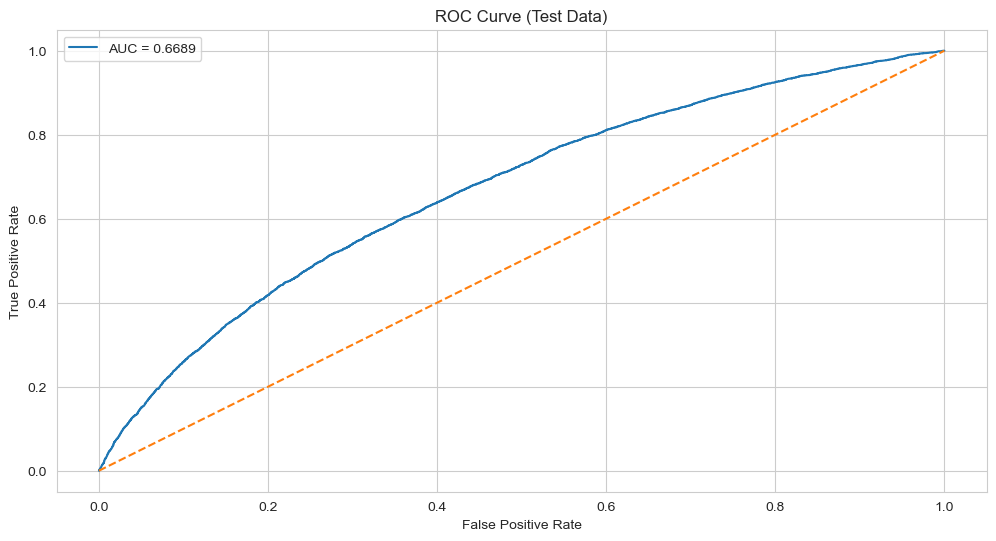

In [15]:
test_pred_prob = logreg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_pred_prob)
auc_score = roc_auc_score(y_test, test_pred_prob)

fpr, tpr, _ = roc_curve(y_test, test_pred_prob)
ks = np.max(tpr - fpr)

print(f"KS Score: {ks:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend()
plt.show()

# Scorecard

## Scorecard Creation

In [16]:
PDO = 20
TARGET_SCORE = 600
TARGET_ODDS = 1/50

card = sc.scorecard(
    bins_final,              
    logreg,
    xcolumns=top_15_vars,
    points0=TARGET_SCORE,
    odds0=TARGET_ODDS,
    pdo=PDO,
    basepoints_eq0=True
)

# Combine all scorecard tables into one nice dataframe
# save current display settings
old_max_colwidth = pd.get_option('display.max_colwidth')
old_width = pd.get_option('display.width')

# set for display
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)


def clean_attribute(x):
    if pd.isna(x):
        return x
    
    x = str(x)

    # Clean scorecardpy categorical separator
    x = x.replace('%,%', ', ')
    x = x.replace('%', '')

    # Remove duplicate commas / weird spacing
    x = re.sub(r'\s*,\s*,\s*', ', ', x)
    x = re.sub(r'\s+', ' ', x).strip()

    # Round ugly float precision
    x = re.sub(r'(\d+\.\d+)', lambda m: f"{float(m.group()):.2f}", x)

    # Friendlier interval labels
    if x == 'missing':
        return 'Missing'
    if x.startswith('[-inf,'):
        upper = x.split(',')[1].replace(')', '').replace(']', '')
        return f'< {upper}'
    if x.endswith(',inf)') or x.endswith(',inf]'):
        lower = x.split(',')[0].replace('[', '').replace('(', '')
        return f'≥ {lower}'

    return x

# Build a cleaner scorecard table
dfs = []

for var, df_ in card.items():
    if var == 'basepoints':
        continue

    temp = df_[['variable', 'bin', 'points']].copy()
    temp.columns = ['Characteristic', 'Attribute', 'Points']

    temp['Attribute'] = temp['Attribute'].apply(clean_attribute)
    temp['Points'] = temp['Points'].round(0).astype(int)

    # Repeat characteristic for every row
    dfs.append(temp)

    # Visible spacer row between characteristics
    spacer = pd.DataFrame([[' ', ' ', ' ']], columns=temp.columns)
    dfs.append(spacer)

card_pretty = pd.concat(dfs, ignore_index=True)

display(
    card_pretty.style
    .hide(axis='index')
    .set_properties(subset=['Characteristic'], **{
        'text-align': 'left',
        'white-space': 'nowrap'
    })
    .set_properties(subset=['Attribute'], **{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'word-break': 'break-word',
        'max-width': '700px'
    })
    .set_properties(subset=['Points'], **{
        'text-align': 'center',
        'white-space': 'nowrap'
    })
    .set_properties(**{
        'height': '30px'
    })
)

# reset back to original display setting
pd.set_option('display.max_colwidth', old_max_colwidth)
pd.set_option('display.width', old_width)





print("Variable to coefficient mapping:")
for col, coef in zip(X_train.columns, logreg.coef_[0]):
    print(f"  {col}: {coef:.10f}")

Characteristic,Attribute,Points
DEBT_TO_ANNUITY,< 20.00,36
DEBT_TO_ANNUITY,≥ 20.00,38
,,
EMP_YEARS,Missing,43
EMP_YEARS,< 3.00,32
EMP_YEARS,"[3.00,5.50)",34
EMP_YEARS,"[5.50,11.00)",38
EMP_YEARS,≥ 11.00,44
,,
BUREAU_AVG_CREDIT_AGE,Missing,33


Variable to coefficient mapping:
  AGE_YEARS_woe: 0.4021687793
  BUREAU_ACTIVE_RATE_woe: 0.4575567467
  BUREAU_AVG_CREDIT_AGE_woe: 0.5857069606
  BUREAU_EARLIEST_ENDDATE_woe: -0.4606470783
  BUREAU_MEAN_DEBT_woe: 0.3745056805
  BUREAU_OLDEST_UPDATE_woe: -0.0842629466
  BUREAU_RECENT_CREDIT_woe: 0.3731556632
  DAYS_ID_PUBLISH_woe: 0.2428666471
  DAYS_LAST_PHONE_CHANGE_woe: 0.6308149397
  DEBT_TO_ANNUITY_woe: 0.5063220476
  EMP_YEARS_woe: 0.3572578816
  LTV_RATIO_woe: 0.8611471729
  NAME_INCOME_TYPE_woe: -0.0707232222
  OCCUPATION_TYPE_woe: 0.5816562866
  ORGANIZATION_TYPE_woe: 0.2441888308


## Scorecard Model Evaluation

In [17]:
train_score = sc.scorecard_ply(train, card)
test_score = sc.scorecard_ply(test, card)

Cutoff,Approved (n),Approved (%),Rejected (n),Rejected (%),Defaults in Approved,Default Rate,Defaults Captured
490,52094,100.0000%,0,0.0000%,4689,9.0010%,0.0000%
500,52090,99.9923%,4,0.0077%,4687,8.9979%,0.0427%
510,51886,99.6007%,208,0.3993%,4625,8.9138%,1.3649%
520,50230,96.4219%,1864,3.5781%,4309,8.5785%,8.1041%
530,44614,85.6413%,7480,14.3587%,3461,7.7577%,26.1890%
540,38292,73.5056%,13802,26.4944%,2754,7.1921%,41.2668%
550,31905,61.2451%,20189,38.7549%,2167,6.7920%,53.7855%
560,25661,49.2590%,26433,50.7410%,1601,6.2390%,65.8563%
570,18385,35.2920%,33709,64.7080%,1049,5.7057%,77.6285%
580,10455,20.0695%,41639,79.9305%,478,4.5720%,89.8059%


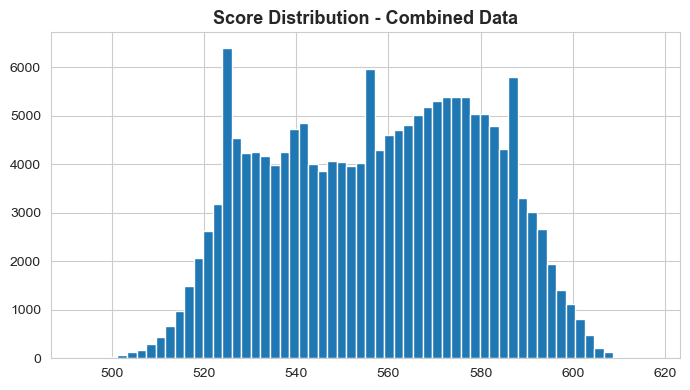

In [18]:
# Cutoff Sensitivity Analysis
scores_col = test_score.columns[0]
scores      = test_score[scores_col].values
actuals     = y_test.values

total       = len(scores)
total_bads  = actuals.sum()

cutoffs = range(
    int(scores.min() // 10) * 10,
    int(scores.max() // 10) * 10 + 20,
    10
)

rows = []
for c in cutoffs:
    approved        = (scores >= c).sum()
    rejected        = total - approved
    approved_bads   = actuals[scores >= c].sum()
    approved_goods  = approved - approved_bads


    rows.append({
    "Cutoff"              : c,
    "Approved (n)"        : approved,
    "Approved (%)"        : f"{approved / total * 100:.4f}%",
    "Rejected (n)"        : rejected,
    "Rejected (%)"        : f"{rejected / total * 100:.4f}%",
    "Defaults in Approved": approved_bads,
    "Default Rate"        : f"{approved_bads / approved * 100:.4f}%" if approved > 0 else "N/A",
    "Defaults Captured"   : f"{(total_bads - approved_bads) / total_bads * 100:.4f}%",
})

cutoff_df = pd.DataFrame(rows)

display(
    cutoff_df.style
    .hide(axis="index")
    .set_caption("Cutoff Sensitivity - Test Set")
    .set_properties(**{"text-align": "center"})
    .set_properties(subset=["Cutoff"], **{"font-weight": "bold"})
)


# Combine train and test scores
combined_score = pd.concat([train_score, test_score], ignore_index=True)

# Plot distribution of scores on combined data
combined_score.hist(figsize=(7, 4), bins=60)
plt.title('Score Distribution - Combined Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
cutoff = 570 # Set cutoff based on sensitivity analysis and business requirements

# create sets of predicted bad to compare with actual bad
predicted_bad_train = (train_score < cutoff)
predicted_bad_train_list = predicted_bad_train.astype(int).values.flatten().tolist()
predicted_bad_test = (test_score < cutoff)
predicted_bad_test_list = predicted_bad_test.astype(int).values.flatten().tolist()

print('*** Training Data Performance ***')
print('Confusion matrix:')
print(metrics.confusion_matrix(y_train, predicted_bad_train_list))
print('PCC measures:')
print(metrics.classification_report(y_train, predicted_bad_train_list))

print('*** Test Data Performance ***')
print('Confusion matrix:')
print(metrics.confusion_matrix(y_test, predicted_bad_test_list))
print('PCC measures:')
print(metrics.classification_report(y_test, predicted_bad_test_list))

*** Training Data Performance ***
Confusion matrix:
[[40829 69784]
 [ 2378  8562]]
PCC measures:
              precision    recall  f1-score   support

           0       0.94      0.37      0.53    110613
           1       0.11      0.78      0.19     10940

    accuracy                           0.41    121553
   macro avg       0.53      0.58      0.36    121553
weighted avg       0.87      0.41      0.50    121553

*** Test Data Performance ***
Confusion matrix:
[[17336 30069]
 [ 1049  3640]]
PCC measures:
              precision    recall  f1-score   support

           0       0.94      0.37      0.53     47405
           1       0.11      0.78      0.19      4689

    accuracy                           0.40     52094
   macro avg       0.53      0.57      0.36     52094
weighted avg       0.87      0.40      0.50     52094



=== Scorecard Metrics & Evaluation (Cutoff = 570) ===


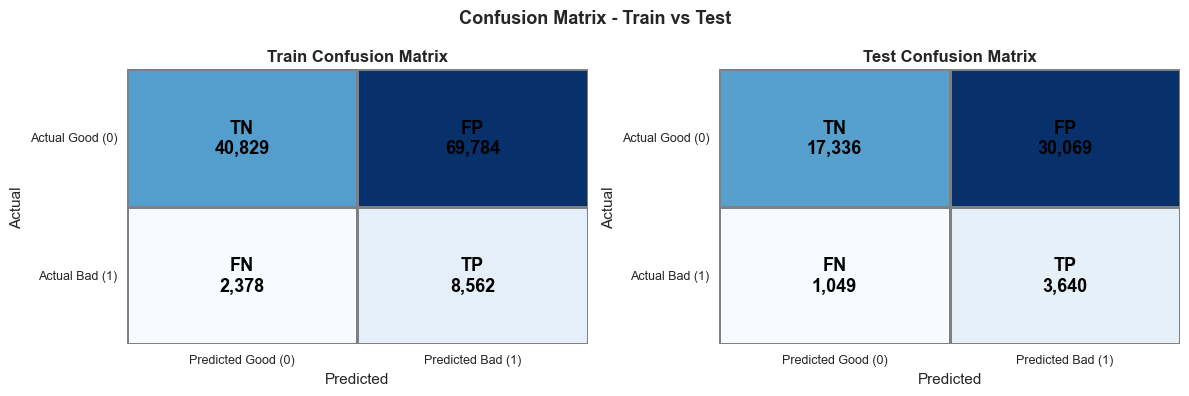

*** PCC Metrics Summary Table ***


Metric,Train,Test,Difference
Accuracy,0.4063,0.4027,-0.36%
Error Rate,0.5937,0.5973,0.36%
Precision,0.1093,0.1080,-0.13%
Recall,0.7826,0.7763,-0.63%
Specificity,0.3691,0.3657,-0.34%
F1 Score,0.1918,0.1896,-0.22%




*** AUC and Gini Summary ***
Metric                    Train       Test
------------------------------------------
AUC                      0.6697     0.6689
Gini Coefficient         0.3395     0.3378


*** KS on Scorecard Scores***
Metric                              Train       Test
----------------------------------------------------
KS (logit probabilities)           0.2460     0.2430
KS (scorecard points)              0.1733     0.1697





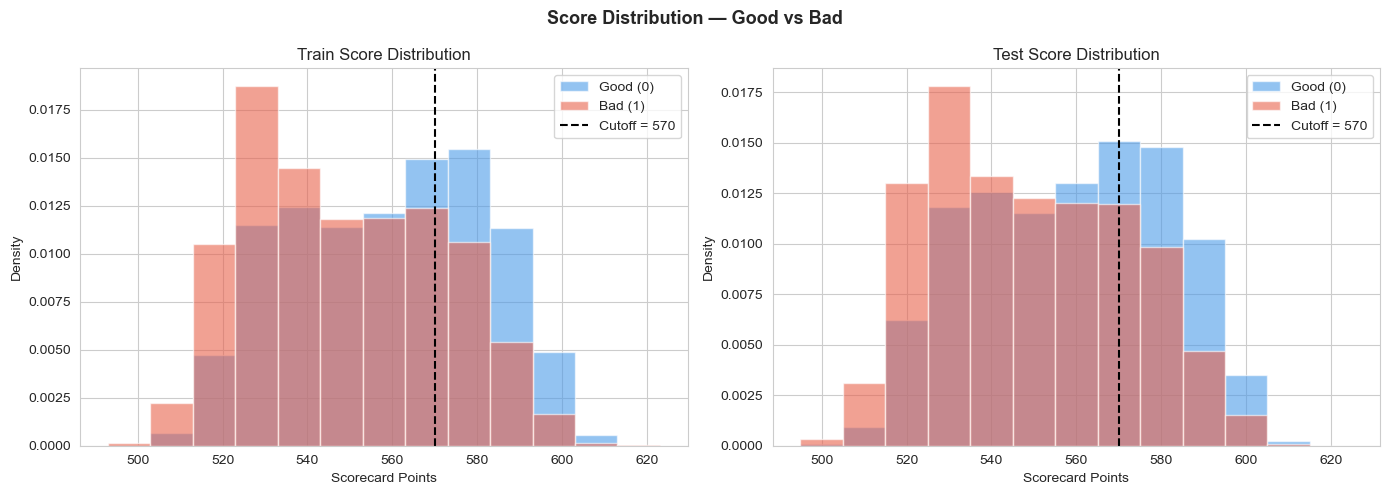

In [20]:
print(f'=== Scorecard Metrics & Evaluation (Cutoff = {cutoff}) ===')
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    error_rate  = 1 - accuracy
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {
        'Accuracy'   : round(accuracy, 4),
        'Error Rate' : round(error_rate, 4),
        'Precision'  : round(precision, 4),
        'Recall'     : round(recall, 4),
        'Specificity': round(specificity, 4),
        'F1 Score'   : round(f1, 4),
    }

train_metrics = get_metrics(y_train, predicted_bad_train_list)
test_metrics  = get_metrics(y_test,  predicted_bad_test_list)




# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, label in [
    (axes[0], y_train, predicted_bad_train_list, 'Train'),
    (axes[1], y_test,  predicted_bad_test_list,  'Test')
]:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm, ax=ax, cmap='Blues', cbar=False,
        linewidths=1, linecolor='gray',
        annot=False
    )

    for (row, col, text) in [
        (0, 0, f'TN\n{tn:,}'),
        (0, 1, f'FP\n{fp:,}'),
        (1, 0, f'FN\n{fn:,}'),
        (1, 1, f'TP\n{tp:,}'),
    ]:
        ax.text(col + 0.5, row + 0.5, text,
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='black')

    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{label} Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Predicted Good (0)', 'Predicted Bad (1)'], fontsize=9)
    ax.set_yticklabels(['Actual Good (0)', 'Actual Bad (1)'], fontsize=9, rotation=0)

plt.suptitle('Confusion Matrix - Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()




# PCC Metrics Summary Table
metrics_df = pd.DataFrame({
    'Metric': list(train_metrics.keys()),
    'Train' : list(train_metrics.values()),
    'Test'  : list(test_metrics.values()),
})

print('*** PCC Metrics Summary Table ***')
display(
    metrics_df.assign(Difference=((metrics_df['Test'] - metrics_df['Train']) * 100).round(2).astype(str) + '%').style
    .hide(axis='index')
    .format({'Train': '{:.4f}', 'Test': '{:.4f}'})
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Metric'], **{'text-align': 'left', 'font-weight': 'bold'})
)




# AUC and Gini Summary
train_pred_prob = logreg.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, train_pred_prob)
test_auc  = roc_auc_score(y_test,  test_pred_prob)

train_gini = 2 * train_auc - 1
test_gini  = 2 * test_auc  - 1

print('\n\n*** AUC and Gini Summary ***')
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'AUC':<20} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Gini Coefficient':<20} {train_gini:>10.4f} {test_gini:>10.4f}")




# KS Statistic on Scorecard Scores
def ks_from_scores(scores_df, y_true):
    scores = scores_df.iloc[:, 0].values
    df_ks = pd.DataFrame({'score': scores, 'target': y_true.values})
    df_ks = df_ks.sort_values('score')
    total_bad  = (df_ks['target'] == 1).sum()
    total_good = (df_ks['target'] == 0).sum()
    df_ks['cum_bad']  = (df_ks['target'] == 1).cumsum() / total_bad
    df_ks['cum_good'] = (df_ks['target'] == 0).cumsum() / total_good
    ks = (df_ks['cum_bad'] - df_ks['cum_good']).abs().max()
    return round(ks, 4)

# Compute KS on logit probabilities for both train and test
train_pred_prob_ks = logreg.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, train_pred_prob_ks)
ks_logit_train = np.max(tpr_train - fpr_train)
ks_logit_test  = np.max(tpr - fpr)  # tpr/fpr from test set

ks_train_score = ks_from_scores(train_score, y_train)
ks_test_score  = ks_from_scores(test_score,  y_test)

print('\n\n*** KS on Scorecard Scores***')
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print("-" * 52)
print(f"{'KS (logit probabilities)':<30} {ks_logit_train:>10.4f} {ks_logit_test:>10.4f}")
print(f"{'KS (scorecard points)':<30} {ks_train_score:>10.4f} {ks_test_score:>10.4f}")




# Score Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores_df, y_true, label in [
    (axes[0], train_score, y_train, 'Train'),
    (axes[1], test_score,  y_test,  'Test')
]:
    scores      = scores_df.iloc[:, 0]
    good_scores = scores[y_true == 0]
    bad_scores  = scores[y_true == 1]

    bins_range = range(int(scores.min()), int(scores.max()) + 10, 10)

    ax.hist(good_scores, bins=bins_range, alpha=0.6, color='#4C9BE8', label='Good (0)', density=True)
    ax.hist(bad_scores,  bins=bins_range, alpha=0.6, color='#E8624C', label='Bad (1)',  density=True)
    ax.axvline(cutoff, color='black', linestyle='--', linewidth=1.5, label=f'Cutoff = {cutoff}')
    ax.set_xlabel('Scorecard Points')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} Score Distribution')
    ax.legend()

print('\n\n')
plt.suptitle('Score Distribution — Good vs Bad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



LIGHTWEIGHT AUTOMATED TUNING OF DEBT_TO_ANNUITY, EMP_YEARS, AGE_YEARS
Inner-train shape: (91165, 17)
Validation shape : (30388, 17)
Total tuning combinations to evaluate: 12
[INFO] creating woe binning ...
Binning on 91165 rows and 16 columns in 00:00:10
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 91165 rows and 16 columns in 00:00:10
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 91165 rows and 16 columns in 00:00:10
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] creating woe binning ...
Binning on 91165 rows and 16 columns in 00:00:10
[INFO] converting into woe values ...
[INFO] converting in

,DEBT_TO_ANNUITY_breaks,EMP_YEARS_breaks,AGE_YEARS_breaks,valid_auc,valid_ks,valid_pcc
0,"[10.0, 20.0, 30.0]","[3.0, 5.5, 11.0]","[37.0, 42.0, 54.0]",0.67,0.25,0.91
1,"[10.0, 20.0, 30.0]","[2.0, 6.0, 12.0]","[37.0, 42.0, 54.0]",0.67,0.25,0.91
2,"[10.0, 20.0, 30.0]","[3.0, 5.5, 11.0]","[35.0, 45.0, 55.0]",0.67,0.25,0.91
3,"[10.0, 20.0, 30.0]","[2.0, 6.0, 12.0]","[35.0, 45.0, 55.0]",0.67,0.25,0.91
4,"[10.0, 20.0, 30.0]","[2.0, 8.0]","[37.0, 42.0, 54.0]",0.67,0.25,0.91
5,"[10.0, 20.0, 30.0]","[2.0, 8.0]","[35.0, 45.0, 55.0]",0.67,0.25,0.91
6,[20.0],"[3.0, 5.5, 11.0]","[37.0, 42.0, 54.0]",0.67,0.25,0.91
7,[20.0],"[2.0, 6.0, 12.0]","[37.0, 42.0, 54.0]",0.67,0.25,0.91
8,[20.0],"[3.0, 5.5, 11.0]","[35.0, 45.0, 55.0]",0.67,0.25,0.91
9,[20.0],"[2.0, 6.0, 12.0]","[35.0, 45.0, 55.0]",0.67,0.25,0.91



BEST TUNING COMBINATION SELECTED
{'DEBT_TO_ANNUITY': [10.0, 20.0, 30.0], 'EMP_YEARS': [3.0, 5.5, 11.0], 'AGE_YEARS': [37.0, 42.0, 54.0]}
Validation AUC : 0.668967
Validation KS  : 0.253382
Validation PCC : 0.909997
[INFO] creating woe binning ...
Binning on 121553 rows and 16 columns in 00:00:11
[INFO] converting into woe values ...
[INFO] converting into woe values ...
MODEL DISCRIMINATION METRICS


,Dataset,AUC,KS
0,Train,0.67,0.25
1,Test,0.67,0.25


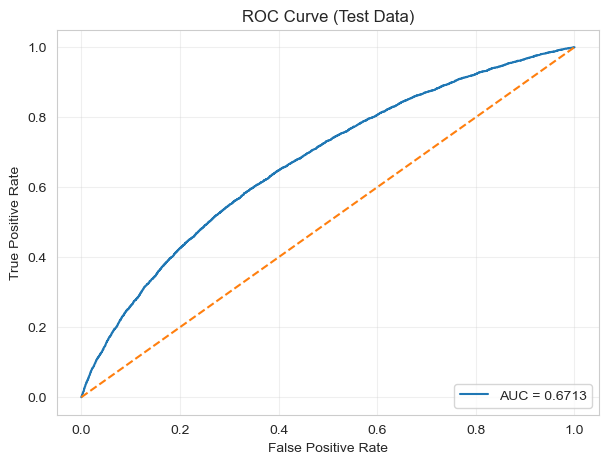


TUNED SCORECARD BINS FOR SELECTED VARIABLES

--- DEBT_TO_ANNUITY ---


,variable,bin,points
0,DEBT_TO_ANNUITY,"[-inf,10.0)",41.00
1,DEBT_TO_ANNUITY,"[10.0,20.0)",35.00
2,DEBT_TO_ANNUITY,"[20.0,30.0)",36.00
3,DEBT_TO_ANNUITY,"[30.0,inf)",40.00



--- EMP_YEARS ---


,variable,bin,points
4,EMP_YEARS,missing,43.00
5,EMP_YEARS,"[-inf,3.0)",32.00
6,EMP_YEARS,"[3.0,5.5)",34.00
7,EMP_YEARS,"[5.5,11.0)",38.00
8,EMP_YEARS,"[11.0,inf)",44.00



--- AGE_YEARS ---


...


Best cutoff by KS_at_Cutoff: 560.0


,Value
Cutoff,560.00
KS_at_Cutoff,0.17
Recall_1_Bads,0.65
Recall_0_Goods,0.52
Approval_Rate,0.50
Bad_Rate_Approved,0.06
Global_Model_KS,0.17
Model_Power_Retained,1.00



FINAL OPERATIONAL METRICS AT BEST SCORE CUTOFF


,Metric,Value
0,Best Score Cutoff,560.00
1,PCC,0.53
2,Recall_1_Bads,0.65
3,Recall_0_Goods,0.52
4,Approval_Rate,0.50
5,Bad_Rate_Approved,0.06
6,Test AUC,0.67
7,Test KS,0.25



Confusion Matrix at Best Score Cutoff:
[[24650 22755]
 [ 1624  3065]]


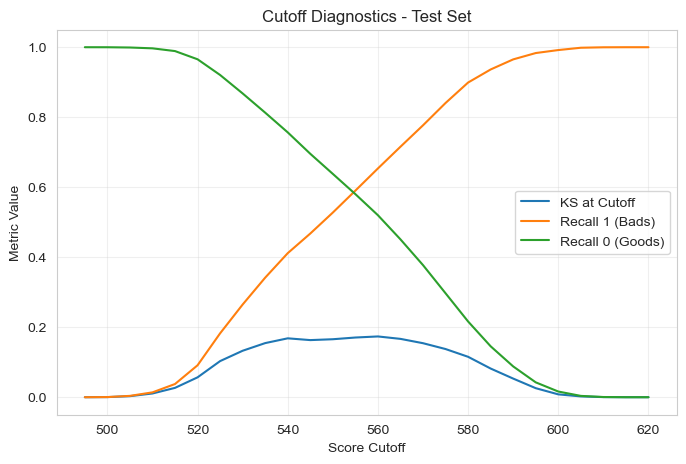


FINAL SUMMARY


,Item,Value
0,Best DEBT_TO_ANNUITY breaks,"[10.0, 20.0, 30.0]"
1,Best EMP_YEARS breaks,"[3.0, 5.5, 11.0]"
2,Best AGE_YEARS breaks,"[37.0, 42.0, 54.0]"
3,Validation AUC (selection stage),0.668967
4,Validation KS (selection stage),0.253382
5,Validation PCC (selection stage),0.909997
6,Final Test AUC,0.671325
7,Final Test KS,0.252637
8,Best Score Cutoff,560.0
9,PCC at Best Cutoff,0.532019


In [21]:
# =============================================================================
# APPEND-ONLY FINAL CELL:
# Lightweight automated tuning for DEBT_TO_ANNUITY, EMP_YEARS, AGE_YEARS
# Total combinations kept under 15
# =============================================================================

import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

from sklearn import linear_model
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score
)

print("="*100)
print("LIGHTWEIGHT AUTOMATED TUNING OF DEBT_TO_ANNUITY, EMP_YEARS, AGE_YEARS")
print("="*100)

# -----------------------------------------------------------------------------
# 0) Use existing notebook objects
# Expected from earlier notebook cells:
# - train, test
# - target
# - top_15_vars
# - breaks_adj (optional existing breaks for other variables)
# -----------------------------------------------------------------------------

base_breaks_adj = dict(breaks_adj) if 'breaks_adj' in globals() else {}
tune_vars = ['DEBT_TO_ANNUITY', 'EMP_YEARS', 'AGE_YEARS']

# -----------------------------------------------------------------------------
# 1) Reduced candidate break grids
# Total combinations = 2 * 3 * 2 = 12
# -----------------------------------------------------------------------------
candidate_breaks = {
    'DEBT_TO_ANNUITY': [
        [20.0],
        [10.0, 20.0, 30.0]
    ],
    'EMP_YEARS': [
        [3.0, 5.5, 11.0],
        [2.0, 6.0, 12.0],
        [2.0, 8.0]
    ],
    'AGE_YEARS': [
        [37.0, 42.0, 54.0],
        [35.0, 45.0, 55.0]
    ]
}

# -----------------------------------------------------------------------------
# 2) Inner validation split from existing train
# -----------------------------------------------------------------------------
dt_inner = sc.split_df(train, y=target, ratio=0.75)
train_inner = dt_inner['train'].copy()
valid_inner = dt_inner['test'].copy()

print(f"Inner-train shape: {train_inner.shape}")
print(f"Validation shape : {valid_inner.shape}")

# -----------------------------------------------------------------------------
# 3) Helper functions
# -----------------------------------------------------------------------------
def pct_correctly_classified(y_true, y_pred):
    return (np.array(y_true) == np.array(y_pred)).mean()

def ks_from_prob(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

def fit_and_score_combo(combo_breaks):
    merged_breaks = dict(base_breaks_adj)
    merged_breaks.update(combo_breaks)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            bins_combo = sc.woebin(
                train_inner,
                y=target,
                x=top_15_vars,
                min_num_bins=2,
                max_num_bins=10,
                positive='bad|1',
                ignore_datetime_cols=False,
                check_cate_num=False,
                breaks_list=merged_breaks
            )

        train_inner_woe = sc.woebin_ply(train_inner, bins_combo, print_step=0)
        valid_inner_woe = sc.woebin_ply(valid_inner, bins_combo, print_step=0)

        woe_cols_combo = sorted([c for c in train_inner_woe.columns if c.endswith('_woe')])

        X_tr = train_inner_woe[woe_cols_combo]
        y_tr = train_inner_woe[target]

        X_va = valid_inner_woe[woe_cols_combo]
        y_va = valid_inner_woe[target]

        model = linear_model.LogisticRegression(
            penalty='l2',
            solver='lbfgs',
            random_state=42,
            max_iter=1000
        )
        model.fit(X_tr, y_tr)

        va_prob = model.predict_proba(X_va)[:, 1]
        va_pred = (va_prob >= 0.5).astype(int)

        return {
            'DEBT_TO_ANNUITY_breaks': combo_breaks['DEBT_TO_ANNUITY'],
            'EMP_YEARS_breaks': combo_breaks['EMP_YEARS'],
            'AGE_YEARS_breaks': combo_breaks['AGE_YEARS'],
            'valid_auc': roc_auc_score(y_va, va_prob),
            'valid_ks': ks_from_prob(y_va, va_prob),
            'valid_pcc': pct_correctly_classified(y_va, va_pred)
        }

    except Exception as e:
        return {
            'DEBT_TO_ANNUITY_breaks': combo_breaks['DEBT_TO_ANNUITY'],
            'EMP_YEARS_breaks': combo_breaks['EMP_YEARS'],
            'AGE_YEARS_breaks': combo_breaks['AGE_YEARS'],
            'valid_auc': np.nan,
            'valid_ks': np.nan,
            'valid_pcc': np.nan,
            'error': str(e)
        }

# -----------------------------------------------------------------------------
# 4) Grid search over 12 combinations
# -----------------------------------------------------------------------------
all_combos = list(itertools.product(
    candidate_breaks['DEBT_TO_ANNUITY'],
    candidate_breaks['EMP_YEARS'],
    candidate_breaks['AGE_YEARS']
))

print(f"Total tuning combinations to evaluate: {len(all_combos)}")

results = []
for debt_b, emp_b, age_b in all_combos:
    combo = {
        'DEBT_TO_ANNUITY': debt_b,
        'EMP_YEARS': emp_b,
        'AGE_YEARS': age_b
    }
    results.append(fit_and_score_combo(combo))

results_df = pd.DataFrame(results)
results_ok = results_df.dropna(subset=['valid_auc', 'valid_ks', 'valid_pcc']).copy()

results_ok = results_ok.sort_values(
    by=['valid_auc', 'valid_ks', 'valid_pcc'],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\nTop tuning combinations:")
display(results_ok)

best_row = results_ok.iloc[0]

best_tuned_breaks = {
    'DEBT_TO_ANNUITY': best_row['DEBT_TO_ANNUITY_breaks'],
    'EMP_YEARS': best_row['EMP_YEARS_breaks'],
    'AGE_YEARS': best_row['AGE_YEARS_breaks']
}

print("\n" + "="*100)
print("BEST TUNING COMBINATION SELECTED")
print("="*100)
print(best_tuned_breaks)
print(f"Validation AUC : {best_row['valid_auc']:.6f}")
print(f"Validation KS  : {best_row['valid_ks']:.6f}")
print(f"Validation PCC : {best_row['valid_pcc']:.6f}")

# -----------------------------------------------------------------------------
# 5) Refit final model on full train using best breaks
# -----------------------------------------------------------------------------
final_breaks_adj = dict(base_breaks_adj)
final_breaks_adj.update(best_tuned_breaks)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bins_best = sc.woebin(
        train,
        y=target,
        x=top_15_vars,
        min_num_bins=2,
        max_num_bins=10,
        positive='bad|1',
        ignore_datetime_cols=False,
        check_cate_num=False,
        breaks_list=final_breaks_adj
    )

train_woe_best = sc.woebin_ply(train, bins_best, print_step=0)
test_woe_best  = sc.woebin_ply(test, bins_best, print_step=0)

woe_cols_best = sorted([c for c in train_woe_best.columns if c.endswith('_woe')])

X_train_best = train_woe_best[woe_cols_best]
y_train_best = train_woe_best[target]

X_test_best = test_woe_best[woe_cols_best]
y_test_best = test_woe_best[target]

logreg_best = linear_model.LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    max_iter=1000
)
logreg_best.fit(X_train_best, y_train_best)
# -----------------------------------------------------------------------------
# 1) Probability-based model discrimination only
#    (keep AUC / KS, but do NOT do 0.5-threshold classification metrics)
# -----------------------------------------------------------------------------
train_prob_best = logreg_best.predict_proba(X_train_best)[:, 1]
test_prob_best  = logreg_best.predict_proba(X_test_best)[:, 1]

def ks_from_prob(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

auc_train = roc_auc_score(y_train_best, train_prob_best)
auc_test  = roc_auc_score(y_test_best, test_prob_best)

ks_train = ks_from_prob(y_train_best, train_prob_best)
ks_test  = ks_from_prob(y_test_best, test_prob_best)

model_eval_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'AUC': [auc_train, auc_test],
    'KS': [ks_train, ks_test]
})

print("="*100)
print("MODEL DISCRIMINATION METRICS")
print("="*100)
display(model_eval_df)

# -----------------------------------------------------------------------------
# 2) ROC Curve
# -----------------------------------------------------------------------------
fpr_test, tpr_test, _ = roc_curve(y_test_best, test_prob_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr_test, tpr_test, label=f"AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Data)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------------------------------------------
# 3) Build scorecard
# -----------------------------------------------------------------------------
PDO = 20
TARGET_SCORE = 600
TARGET_ODDS = 1/50

card_best = sc.scorecard(
    bins_best,
    logreg_best,
    xcolumns=top_15_vars,
    points0=TARGET_SCORE,
    odds0=TARGET_ODDS,
    pdo=PDO,
    basepoints_eq0=True
)

train_score_best = sc.scorecard_ply(train, card_best)
test_score_best  = sc.scorecard_ply(test, card_best)

# Find score column safely
possible_score_cols = [c for c in test_score_best.columns if 'score' in c.lower()]
if len(possible_score_cols) > 0:
    score_col = possible_score_cols[0]
else:
    score_col = test_score_best.columns[0]

train_scores_array = train_score_best[score_col].values
test_scores_array  = test_score_best[score_col].values

# -----------------------------------------------------------------------------
# 4) Show tuned scorecard bins for selected variables
# -----------------------------------------------------------------------------
tune_vars = ['DEBT_TO_ANNUITY', 'EMP_YEARS', 'AGE_YEARS']

print("\n" + "="*100)
print("TUNED SCORECARD BINS FOR SELECTED VARIABLES")
print("="*100)

for var in tune_vars:
    if var in card_best:
        print(f"\n--- {var} ---")
        display(card_best[var])

# -----------------------------------------------------------------------------
# 5) Cutoff evaluation function
# -----------------------------------------------------------------------------
def evaluate_cutoffs(scores, actual, step=5):
    """
    Evaluate score thresholds.
    Assumes lower score = riskier, so predicted_bad = score < cutoff
    """
    scores = np.asarray(scores).flatten()
    actual = np.asarray(actual).astype(int).flatten()

    cutoffs = list(range(
        int(np.floor(scores.min() / step) * step),
        int(np.ceil(scores.max() / step) * step) + step,
        step
    ))

    rows = []
    global_best_ks = -np.inf

    for cutoff in cutoffs:
        predicted_bad = (scores < cutoff).astype(int)

        tn, fp, fn, tp = confusion_matrix(actual, predicted_bad).ravel()

        recall_1_bads = tp / (tp + fn) if (tp + fn) > 0 else 0
        recall_0_goods = tn / (tn + fp) if (tn + fp) > 0 else 0
        approval_rate = np.mean(scores >= cutoff)

        approved_mask = (scores >= cutoff)
        if approved_mask.sum() > 0:
            bad_rate_approved = actual[approved_mask].mean()
        else:
            bad_rate_approved = np.nan

        ks_at_cutoff = recall_1_bads - (1 - recall_0_goods)
        global_best_ks = max(global_best_ks, ks_at_cutoff)

        rows.append({
            'Cutoff': cutoff,
            'KS_at_Cutoff': ks_at_cutoff,
            'Recall_1_Bads': recall_1_bads,
            'Recall_0_Goods': recall_0_goods,
            'Approval_Rate': approval_rate,
            'Bad_Rate_Approved': bad_rate_approved
        })

    out = pd.DataFrame(rows)
    out['Global_Model_KS'] = global_best_ks
    out['Model_Power_Retained'] = np.where(
        out['Global_Model_KS'] != 0,
        out['KS_at_Cutoff'] / out['Global_Model_KS'],
        np.nan
    )

    return out.sort_values(by='KS_at_Cutoff', ascending=False).reset_index(drop=True)

# -----------------------------------------------------------------------------
# 6) Evaluate cutoffs on test score
# -----------------------------------------------------------------------------
cutoff_eval_df = evaluate_cutoffs(test_scores_array, y_test_best.values, step=5)

print("\n" + "="*100)
print("CUTOFF EVALUATION (TEST SET)")
print("="*100)
display(cutoff_eval_df.head(20))

best_cutoff_row = cutoff_eval_df.iloc[0]
best_cutoff = best_cutoff_row['Cutoff']

print(f"\nBest cutoff by KS_at_Cutoff: {best_cutoff}")
display(best_cutoff_row.to_frame(name='Value'))

# -----------------------------------------------------------------------------
# 7) Final operational metrics at best score cutoff
# -----------------------------------------------------------------------------
predicted_bad_test_score = (test_scores_array < best_cutoff).astype(int)

cm_cutoff = confusion_matrix(y_test_best.values, predicted_bad_test_score)
tn, fp, fn, tp = cm_cutoff.ravel()

pcc_cutoff = (predicted_bad_test_score == y_test_best.values).mean()
recall_1_bads = tp / (tp + fn) if (tp + fn) > 0 else np.nan
recall_0_goods = tn / (tn + fp) if (tn + fp) > 0 else np.nan
approval_rate = np.mean(test_scores_array >= best_cutoff)

approved_mask = (test_scores_array >= best_cutoff)
bad_rate_approved = (
    y_test_best.values[approved_mask].mean() if approved_mask.sum() > 0 else np.nan
)

final_cutoff_metrics = pd.DataFrame({
    'Metric': [
        'Best Score Cutoff',
        'PCC',
        'Recall_1_Bads',
        'Recall_0_Goods',
        'Approval_Rate',
        'Bad_Rate_Approved',
        'Test AUC',
        'Test KS'
    ],
    'Value': [
        best_cutoff,
        pcc_cutoff,
        recall_1_bads,
        recall_0_goods,
        approval_rate,
        bad_rate_approved,
        auc_test,
        ks_test
    ]
})

print("\n" + "="*100)
print("FINAL OPERATIONAL METRICS AT BEST SCORE CUTOFF")
print("="*100)
display(final_cutoff_metrics)

print("\nConfusion Matrix at Best Score Cutoff:")
print(cm_cutoff)

# -----------------------------------------------------------------------------
# 8) Plot cutoff diagnostics
# -----------------------------------------------------------------------------
plot_df = cutoff_eval_df.sort_values('Cutoff')

plt.figure(figsize=(8, 5))
plt.plot(plot_df['Cutoff'], plot_df['KS_at_Cutoff'], label='KS at Cutoff')
plt.plot(plot_df['Cutoff'], plot_df['Recall_1_Bads'], label='Recall 1 (Bads)')
plt.plot(plot_df['Cutoff'], plot_df['Recall_0_Goods'], label='Recall 0 (Goods)')
plt.xlabel("Score Cutoff")
plt.ylabel("Metric Value")
plt.title("Cutoff Diagnostics - Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------------------------------------------------------
# 9) Final summary table
# -----------------------------------------------------------------------------
summary_out = pd.DataFrame({
    'Item': [
        'Best DEBT_TO_ANNUITY breaks',
        'Best EMP_YEARS breaks',
        'Best AGE_YEARS breaks',
        'Validation AUC (selection stage)',
        'Validation KS (selection stage)',
        'Validation PCC (selection stage)',
        'Final Test AUC',
        'Final Test KS',
        'Best Score Cutoff',
        'PCC at Best Cutoff',
        'Recall_1_Bads at Best Cutoff',
        'Recall_0_Goods at Best Cutoff',
        'Approval Rate at Best Cutoff',
        'Bad Rate Approved at Best Cutoff'
    ],
    'Value': [
        str(best_tuned_breaks['DEBT_TO_ANNUITY']),
        str(best_tuned_breaks['EMP_YEARS']),
        str(best_tuned_breaks['AGE_YEARS']),
        f"{best_row['valid_auc']:.6f}",
        f"{best_row['valid_ks']:.6f}",
        f"{best_row['valid_pcc']:.6f}",
        f"{auc_test:.6f}",
        f"{ks_test:.6f}",
        str(best_cutoff),
        f"{pcc_cutoff:.6f}",
        f"{recall_1_bads:.6f}",
        f"{recall_0_goods:.6f}",
        f"{approval_rate:.6f}",
        f"{bad_rate_approved:.6f}"
    ]
})

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)
display(summary_out)

In [22]:
train_pred_cutoff = (train_scores_array < best_cutoff).astype(int)
test_pred_cutoff  = (test_scores_array < best_cutoff).astype(int)
print("\nClassification Report (Train, score cutoff):")
print(classification_report(y_train_best, train_pred_cutoff, digits=4))

print("\nConfusion Matrix (Train, score cutoff):")
print(confusion_matrix(y_train_best, train_pred_cutoff))

print("\nClassification Report (Test, score cutoff):")
print(classification_report(y_test_best, test_pred_cutoff, digits=4))

print("\nConfusion Matrix (Test, score cutoff):")
print(confusion_matrix(y_test_best, test_pred_cutoff))


Classification Report (Train, score cutoff):
              precision    recall  f1-score   support

           0     0.9389    0.5229    0.6717    110613
           1     0.1197    0.6561    0.2025     10940

    accuracy                         0.5349    121553
   macro avg     0.5293    0.5895    0.4371    121553
weighted avg     0.8652    0.5349    0.6295    121553


Confusion Matrix (Train, score cutoff):
[[57840 52773]
 [ 3762  7178]]

Classification Report (Test, score cutoff):
              precision    recall  f1-score   support

           0     0.9382    0.5200    0.6691     47405
           1     0.1187    0.6537    0.2009      4689

    accuracy                         0.5320     52094
   macro avg     0.5284    0.5868    0.4350     52094
weighted avg     0.8644    0.5320    0.6270     52094


Confusion Matrix (Test, score cutoff):
[[24650 22755]
 [ 1624  3065]]
